In [3]:
# =========================
# Standard library imports
# =========================
import sys
import os
import io
import gzip
from pathlib import Path
import math
import json
import pickle
import logging
import random
import subprocess
import warnings
import collections
import itertools
import re
from IPython.display import display

warnings.filterwarnings("ignore")


# =========================
# Numeric / stats
# =========================
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from scipy.stats import rankdata
from scipy import __version__ as scipy_version


# =========================
# Plotting / visualization
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FormatStrFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import seaborn as sns


# =========================
# scikit-learn
# =========================
from sklearn import model_selection, metrics
from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    KFold,
    GroupKFold,
    cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn import __version__ as sklearn_version


# =========================
# Optimization / AutoML
# =========================
import optuna


# =========================
# LightGBM
# =========================
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except Exception as e:
    _HAS_LGBM = False
    raise RuntimeError(
        "LightGBM not installed. Please install it with `pip install lightgbm`."
    ) from e


# =========================
# RNA structure (ViennaRNA)
# =========================
import RNA


# =========================
# UpSet plots
# =========================
try:
    from upsetplot import UpSet, from_memberships
except Exception:
    _ = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "upsetplot"],
        check=False,
    )
    from upsetplot import UpSet, from_memberships


# =========================
# Model explanation
# =========================
import shap


# =========================
# User-provided utilities
# =========================
import sylib  


# =========================
# Version info
# =========================
print(f"python    = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas    = {pd.__version__}")
print(f"numpy     = {np.__version__}")
print(f"scipy     = {scipy_version}")
print(f"optuna    = {optuna.__version__}")
print(f"sklearn   = {sklearn_version}")
print(f"ViennaRNA = {RNA.__version__}")
print(f"lightgbm  = {lgb.__version__}")
print(f"sylib     = {sylib.__version__}")


# =========================
# Progress bar & logging
# =========================
# progress bar from sylib
progress_bar = sylib.utils.ProgressBar()

# reset handlers then configure logging
logging.root.handlers = []
stream_handler = logging.StreamHandler(sys.stderr)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)
logger = logging.getLogger(__name__)

# make matplotlib quieter
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python    = 3.11.15
pandas    = 2.3.3
numpy     = 2.4.6
scipy     = 1.17.1
optuna    = 4.9.0
sklearn   = 1.9.0
ViennaRNA = 2.7.2
lightgbm  = 4.6.0
sylib     = 0.3.0.dev0+ae18bb2


In [23]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=10,
    title_fontsize=12,
    label_fontsize=10,
    tick_fontsize=9,
    legend_fontsize=10,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

# ============================================
# Plot helper functions
# ============================================

def species_palette():
    return [
        SPECIES_INFO["AT21"]["color"],
        SPECIES_INFO["NB21"]["color"],
        SPECIES_INFO["OS21"]["color"],
    ]


def outside_legend(
    ax,
    *,
    title="Species",
    n_items=3,
    x=1.02,
    y=1.00,
):
    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:n_items],
        labels[:n_items],
        title=title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(x, y),
        borderaxespad=0,
    )

    return ax

In [4]:
# ============================================
# Setup
# ============================================

RESULT_DIR = Path("../results")
SPECIES = ["AT21", "NB21", "OS21"]

SPECIES_INFO = {
    "AT21": {"label": "AT", "color": "#664D0AFF", "marker": "o"},
    "NB21": {"label": "NB", "color": "#7e3131", "marker": "^"},
    "OS21": {"label": "OS", "color": "#13563f", "marker": "s"},
}

_PLOT_CFG = {"fig_w": 6.0, "fig_h": 6.0, "dpi": 300}

sns.set_style("ticks")
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 10, "figure.dpi": 300,
    "savefig.dpi": 300, "axes.linewidth": 1.2, "axes.spines.top": True,
    "axes.spines.right": True, "axes.grid": False, "xtick.major.size": 6,
    "ytick.major.size": 6, "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "savefig.bbox": "tight",
})

In [5]:
# ============================================
# Plot helpers
# ============================================

def make_fig(w=None, h=None, dpi=None):
    return plt.subplots(
        figsize=(w or _PLOT_CFG["fig_w"], h or _PLOT_CFG["fig_h"]),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

def format_axis(ax, *, xlabel=None, ylabel=None):
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    return ax

In [6]:
# ============================================
# Feature annotation
# ============================================

def extract_region(feature):
    if feature.startswith("5'UTR."): return "5'UTR"
    if feature.startswith("CDS."): return "CDS"
    if feature.startswith("3'UTR."): return "3'UTR"
    return "mRNA"

def extract_feature_type(feature):
    if feature.endswith(".Length"): return "Length"
    if ".uAUG" in feature or ".uORF" in feature or ".dAUG" in feature or ".dORF" in feature: return "ORF_nonCDS"
    if feature.endswith(".MFE"): return "RNA_structure_MFE"
    if ".wobble_pct_" in feature: return "Wobble"
    if ".aa_pct_" in feature: return "Amino_acid_composition"
    if ".dicodon_" in feature: return "Dicodon"
    if re.search(r"\.[A-Z][a-z]{2}-[AUGC]{3}$", feature): return "Codon_usage"
    if feature.endswith("-freq"): return "Nucleotide_kmer_freq"
    return "Other"

In [7]:
# ============================================
# Load LightGBM feature importance
# ============================================

importance_rows = []

for species_key in SPECIES:
    path = RESULT_DIR / "lgbm" / f"{species_key}.lgbm.feature_importance.tsv"
    temp = pd.read_csv(path, sep="\t")[["feature", "importance"]].copy()
    temp["Species_key"] = species_key
    temp["Species"] = SPECIES_INFO[species_key]["label"]
    importance_rows.append(temp)

importance_long = pd.concat(importance_rows, ignore_index=True).rename(
    columns={"feature": "Feature", "importance": "Importance_raw"}
)

importance_long["Region"] = importance_long["Feature"].apply(extract_region)
importance_long["Feature_type"] = importance_long["Feature"].apply(extract_feature_type)

print("LightGBM feature importance:", importance_long.shape)
display(importance_long.head())

# ============================================
# Normalize feature importance within species
# ============================================

importance_matrix = (
    importance_long
    .pivot(index="Feature", columns="Species_key", values="Importance_raw")
    .reindex(columns=SPECIES)
    .fillna(0)
)

importance_norm = importance_matrix.div(importance_matrix.sum(axis=0), axis=1)

print("Importance matrix:", importance_matrix.shape)
print("Normalized sums")
display(importance_norm.sum(axis=0))

LightGBM feature importance: (1304, 6)


,Feature,Importance_raw,Species_key,Species,Region,Feature_type
0,5'UTR.CUU-freq,29.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
1,5'UTR.C-freq,28.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
2,5'UTR.S-freq,27.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
3,5'UTR.U-freq,26.0,AT21,AT,5'UTR,Nucleotide_kmer_freq
4,5'UTR.MFE,25.0,AT21,AT,5'UTR,RNA_structure_MFE


Importance matrix: (449, 3)
Normalized sums


Species_key
AT21    1.0
NB21    1.0
OS21    1.0
dtype: float64

In [8]:
# ============================================
# Species Specificity Score (SSS)
# ============================================

AT, NB, OS = importance_norm["AT21"], importance_norm["NB21"], importance_norm["OS21"]

sss_df = pd.DataFrame({
    "AT_SSS": np.sqrt((AT - NB) ** 2 + (AT - OS) ** 2),
    "NB_SSS": np.sqrt((NB - AT) ** 2 + (NB - OS) ** 2),
    "OS_SSS": np.sqrt((OS - AT) ** 2 + (OS - NB) ** 2),
    "AT_Delta": AT - (NB + OS) / 2,
    "NB_Delta": NB - (AT + OS) / 2,
    "OS_Delta": OS - (AT + NB) / 2,
}).reset_index()

sss_df["Region"] = sss_df["Feature"].apply(extract_region)
sss_df["Feature_type"] = sss_df["Feature"].apply(extract_feature_type)

print("SSS table:", sss_df.shape)
display(sss_df.head())

# ============================================
# Long-format SSS + normalized importance
# ============================================

sss_long = pd.concat([
    sss_df[["Feature", "Region", "Feature_type", f"{sp}_SSS", f"{sp}_Delta"]]
    .rename(columns={f"{sp}_SSS": "SSS", f"{sp}_Delta": "Delta"})
    .assign(Species=sp)
    for sp in ["AT", "NB", "OS"]
], ignore_index=True)

importance_norm_long = (
    importance_norm.reset_index()
    .melt(id_vars="Feature", var_name="Species_key", value_name="Importance_normalized")
)

importance_norm_long["Species"] = importance_norm_long["Species_key"].map({
    "AT21": "AT", "NB21": "NB", "OS21": "OS"
})

candidate_df = (
    sss_long
    .merge(
        importance_norm_long[["Feature", "Species", "Importance_normalized"]],
        on=["Feature", "Species"], how="left", validate="one_to_one"
    )
)

print("Candidate table:", candidate_df.shape)
display(candidate_df.head())

SSS table: (449, 9)


,Feature,AT_SSS,NB_SSS,OS_SSS,AT_Delta,NB_Delta,OS_Delta,Region,Feature_type
0,3'UTR.A-freq,0.002228,0.002049,0.003016,-0.001200,-0.000931,0.002131,3'UTR,Nucleotide_kmer_freq
1,3'UTR.AA-freq,0.002280,0.003303,0.002395,0.001081,-0.002335,0.001254,3'UTR,Nucleotide_kmer_freq
2,3'UTR.AAA-freq,0.002856,0.002504,0.001772,-0.001981,0.001584,0.000397,3'UTR,Nucleotide_kmer_freq
3,3'UTR.AAC-freq,0.002329,0.002022,0.001447,0.001617,-0.001271,-0.000347,3'UTR,Nucleotide_kmer_freq
4,3'UTR.AAG-freq,0.001495,0.001762,0.002278,0.000599,0.001006,-0.001605,3'UTR,Nucleotide_kmer_freq


Candidate table: (1347, 7)


,Feature,Region,Feature_type,SSS,Delta,Species,Importance_normalized
0,3'UTR.A-freq,3'UTR,Nucleotide_kmer_freq,0.002228,-0.001200,AT,0.001579
1,3'UTR.AA-freq,3'UTR,Nucleotide_kmer_freq,0.002280,0.001081,AT,0.003684
2,3'UTR.AAA-freq,3'UTR,Nucleotide_kmer_freq,0.002856,-0.001981,AT,0.000789
3,3'UTR.AAC-freq,3'UTR,Nucleotide_kmer_freq,0.002329,0.001617,AT,0.003684
4,3'UTR.AAG-freq,3'UTR,Nucleotide_kmer_freq,0.001495,0.000599,AT,0.002895


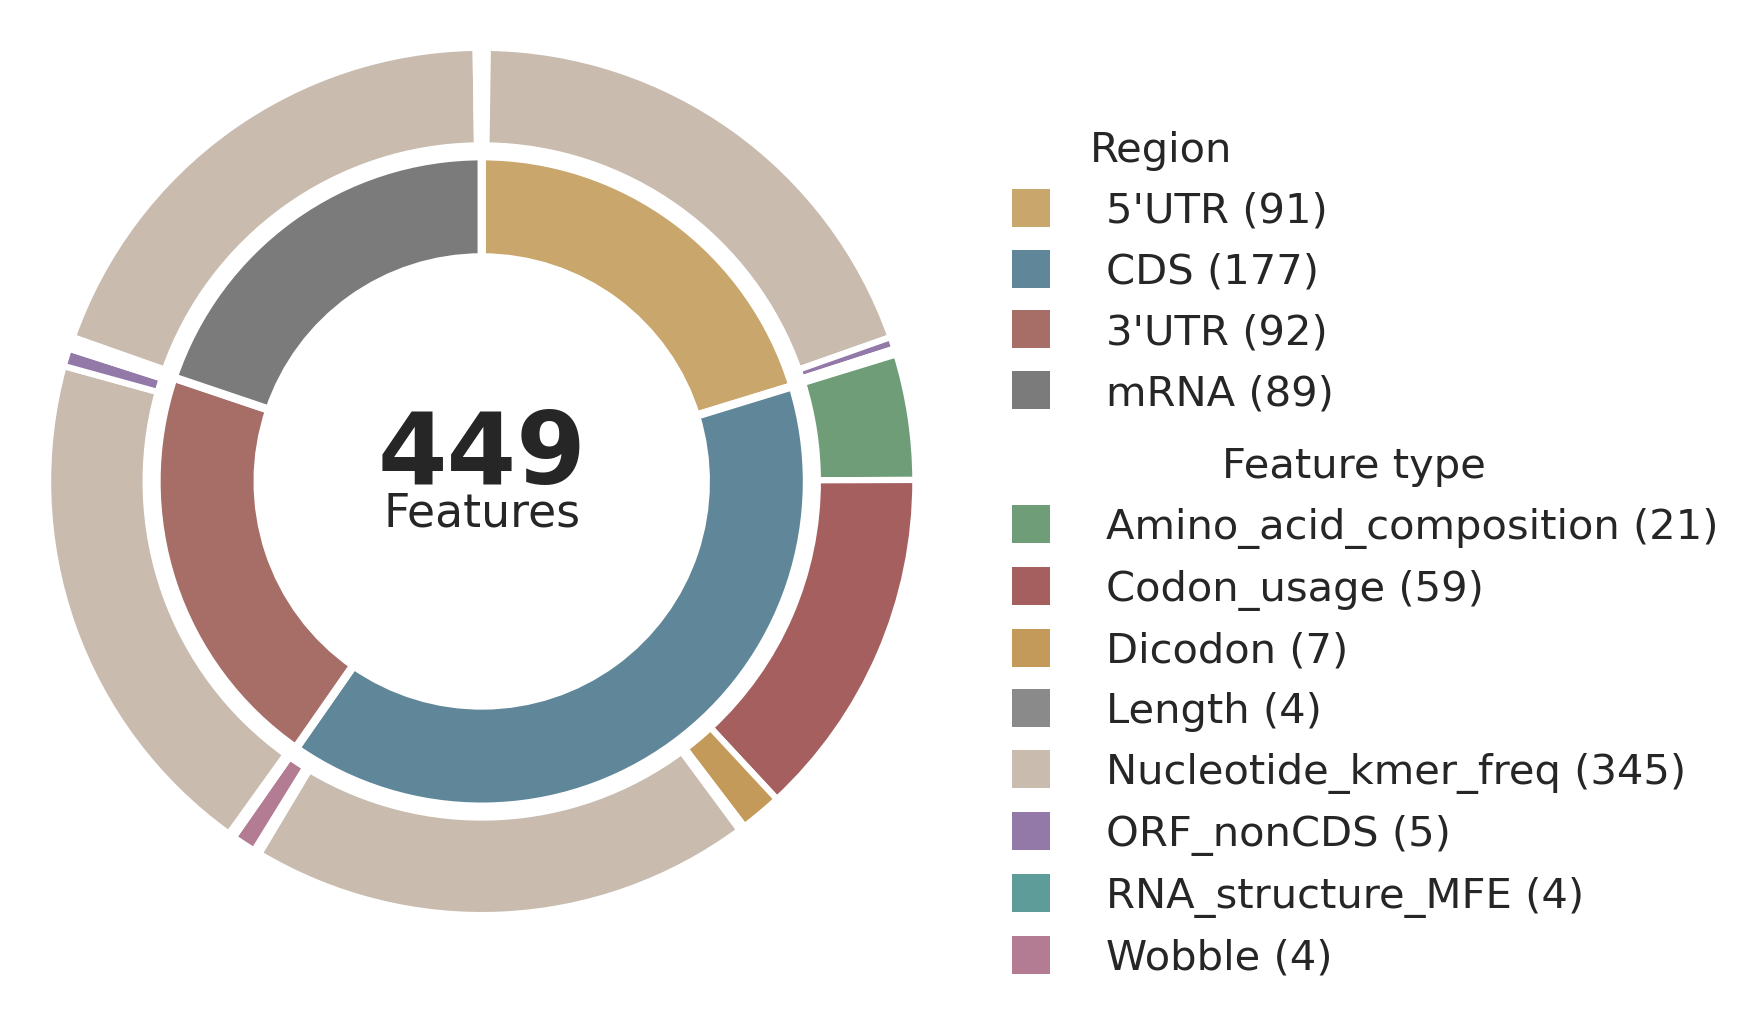

In [31]:
# ============================================
# Nested donut: Region → Feature type
# ============================================

plot_df = sss_df[["Feature", "Region", "Feature_type"]].drop_duplicates()

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]
plot_df["Region"] = pd.Categorical(
    plot_df["Region"],
    categories=region_order,
    ordered=True,
)

region_counts = (
    plot_df.groupby("Region", observed=True)
    .size()
    .reindex(region_order)
)

nested_counts = (
    plot_df.groupby(["Region", "Feature_type"], observed=True)
    .size()
    .reset_index(name="Count")
    .sort_values(["Region", "Feature_type"])
)

# Colors
region_colors = dict(zip(
    region_order,
    sns.color_palette("Set1", len(region_order))
))

feature_types = sorted(plot_df["Feature_type"].unique())
feature_colors = dict(zip(
    feature_types,
    sns.color_palette("Set2", len(feature_types))
))

fig, ax = plt.subplots(
    figsize=(6, 6),
    dpi=_PLOT_CFG["dpi"],
)

# ============================================
# Muted presentation palette
# ============================================

region_colors = {
    "5'UTR": "#C9A66B",   # muted ochre
    "CDS":   "#5F8799",   # muted blue
    "3'UTR": "#A76D67",   # muted red
    "mRNA":  "#7B7B7B",   # gray
}

feature_colors = {
    "Nucleotide_kmer_freq":    "#C9BBAE",
    "Codon_usage":             "#A65F5F",
    "Amino_acid_composition":  "#6F9D78",
    "Dicodon":                 "#C49A5A",
    "ORF_nonCDS":              "#9279A8",
    "Length":                  "#8A8A8A",
    "RNA_structure_MFE":       "#5E9C9A",
    "Wobble":                  "#B47C93",
}

# --------------------------------------------
# Inner ring: Region
# --------------------------------------------

inner_colors = [
    region_colors[r]
    for r in region_counts.index
]

inner_wedges, _ = ax.pie(
    region_counts.values,
    radius=0.90,
    startangle=90,
    counterclock=False,
    colors=inner_colors,
    wedgeprops=dict(
        width=0.28,
        edgecolor="white",
        linewidth=2,
    ),
)

# --------------------------------------------
# Outer ring: Feature types nested by Region
# --------------------------------------------

outer_colors = [
    feature_colors[t]
    for t in nested_counts["Feature_type"]
]

outer_wedges, _ = ax.pie(
    nested_counts["Count"].values,
    radius=1.20,
    startangle=90,
    counterclock=False,
    colors=outer_colors,
    wedgeprops=dict(
        width=0.27,
        edgecolor="white",
        linewidth=1.5,
    ),
)

# --------------------------------------------
# Center
# --------------------------------------------

ax.text(
    0, 0.07,
    f"{len(plot_df)}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
)

ax.text(
    0, -0.09,
    "Features",
    ha="center",
    va="center",
    fontsize=11,
)

# --------------------------------------------
# Legends
# --------------------------------------------

region_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=9,
        markerfacecolor=region_colors[r],
        markeredgecolor="none",
        label=f"{r} ({region_counts[r]})",
    )
    for r in region_order
]

feature_counts = (
    plot_df["Feature_type"]
    .value_counts()
)

feature_handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=9,
        markerfacecolor=feature_colors[t],
        markeredgecolor="none",
        label=f"{t} ({feature_counts[t]})",
    )
    for t in feature_types
]

leg1 = ax.legend(
    handles=region_handles,
    title="Region",
    bbox_to_anchor=(1.02, 0.93),
    loc="upper left",
    frameon=False,
)

ax.add_artist(leg1)

ax.legend(
    handles=feature_handles,
    title="Feature type",
    bbox_to_anchor=(1.02, 0.58),
    loc="upper left",
    frameon=False,
)

# ax.set_title(
#     "Sequence Feature Space",
#     fontsize=15,
#     fontweight="bold",
# )

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

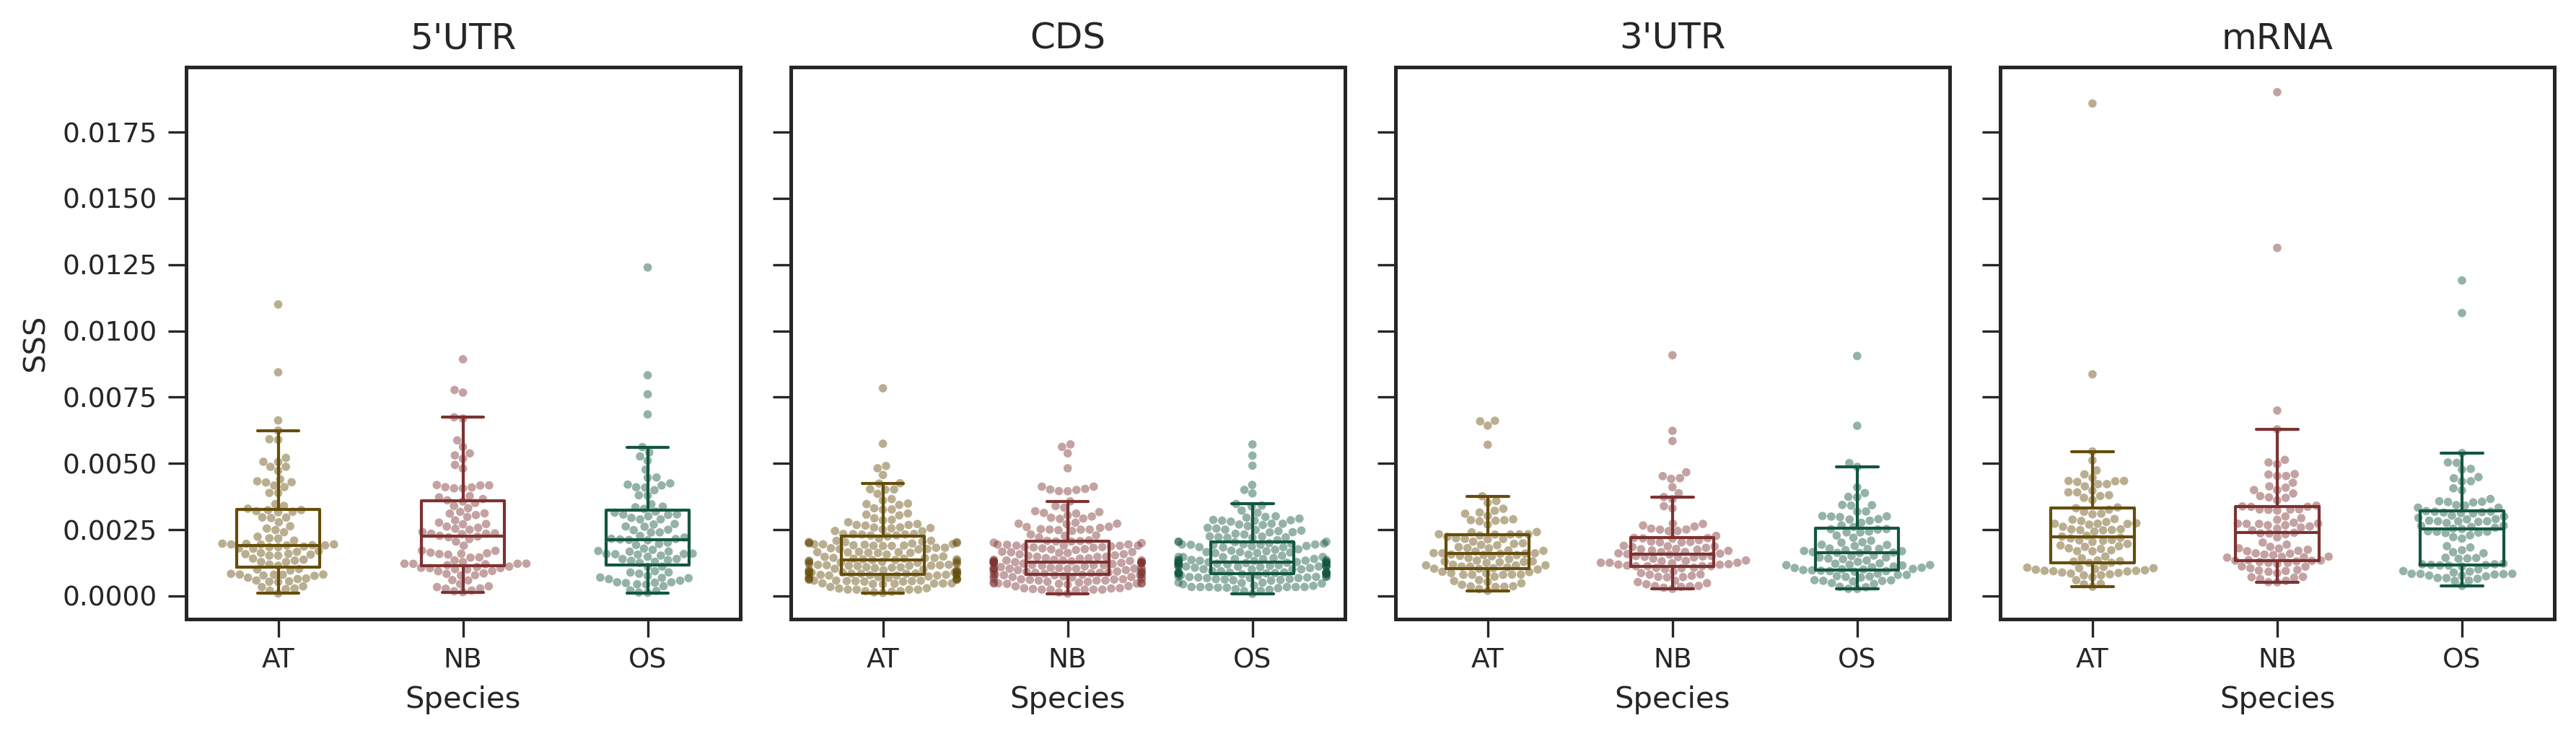

In [9]:
# ============================================
# SSS distribution by transcript region
# Boxplot + beeswarm
# ============================================

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]
species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"], sharey=True)

for ax, region in zip(axes, region_order):
    temp = sss_long.loc[sss_long["Region"] == region]

    sns.boxplot(
        data=temp, x="Species", y="SSS", order=species_order, palette=palette,
        width=0.45, showfliers=False, fill=False, linewidth=1, ax=ax,
    )

    sns.swarmplot(
        data=temp, x="Species", y="SSS", order=species_order, palette=palette,
        size=2.8, alpha=0.45, linewidth=0, ax=ax,
    )

    ax.set_title(region)
    format_axis(ax, xlabel=None, ylabel="SSS" if ax is axes[0] else None)

plt.tight_layout()
plt.show()

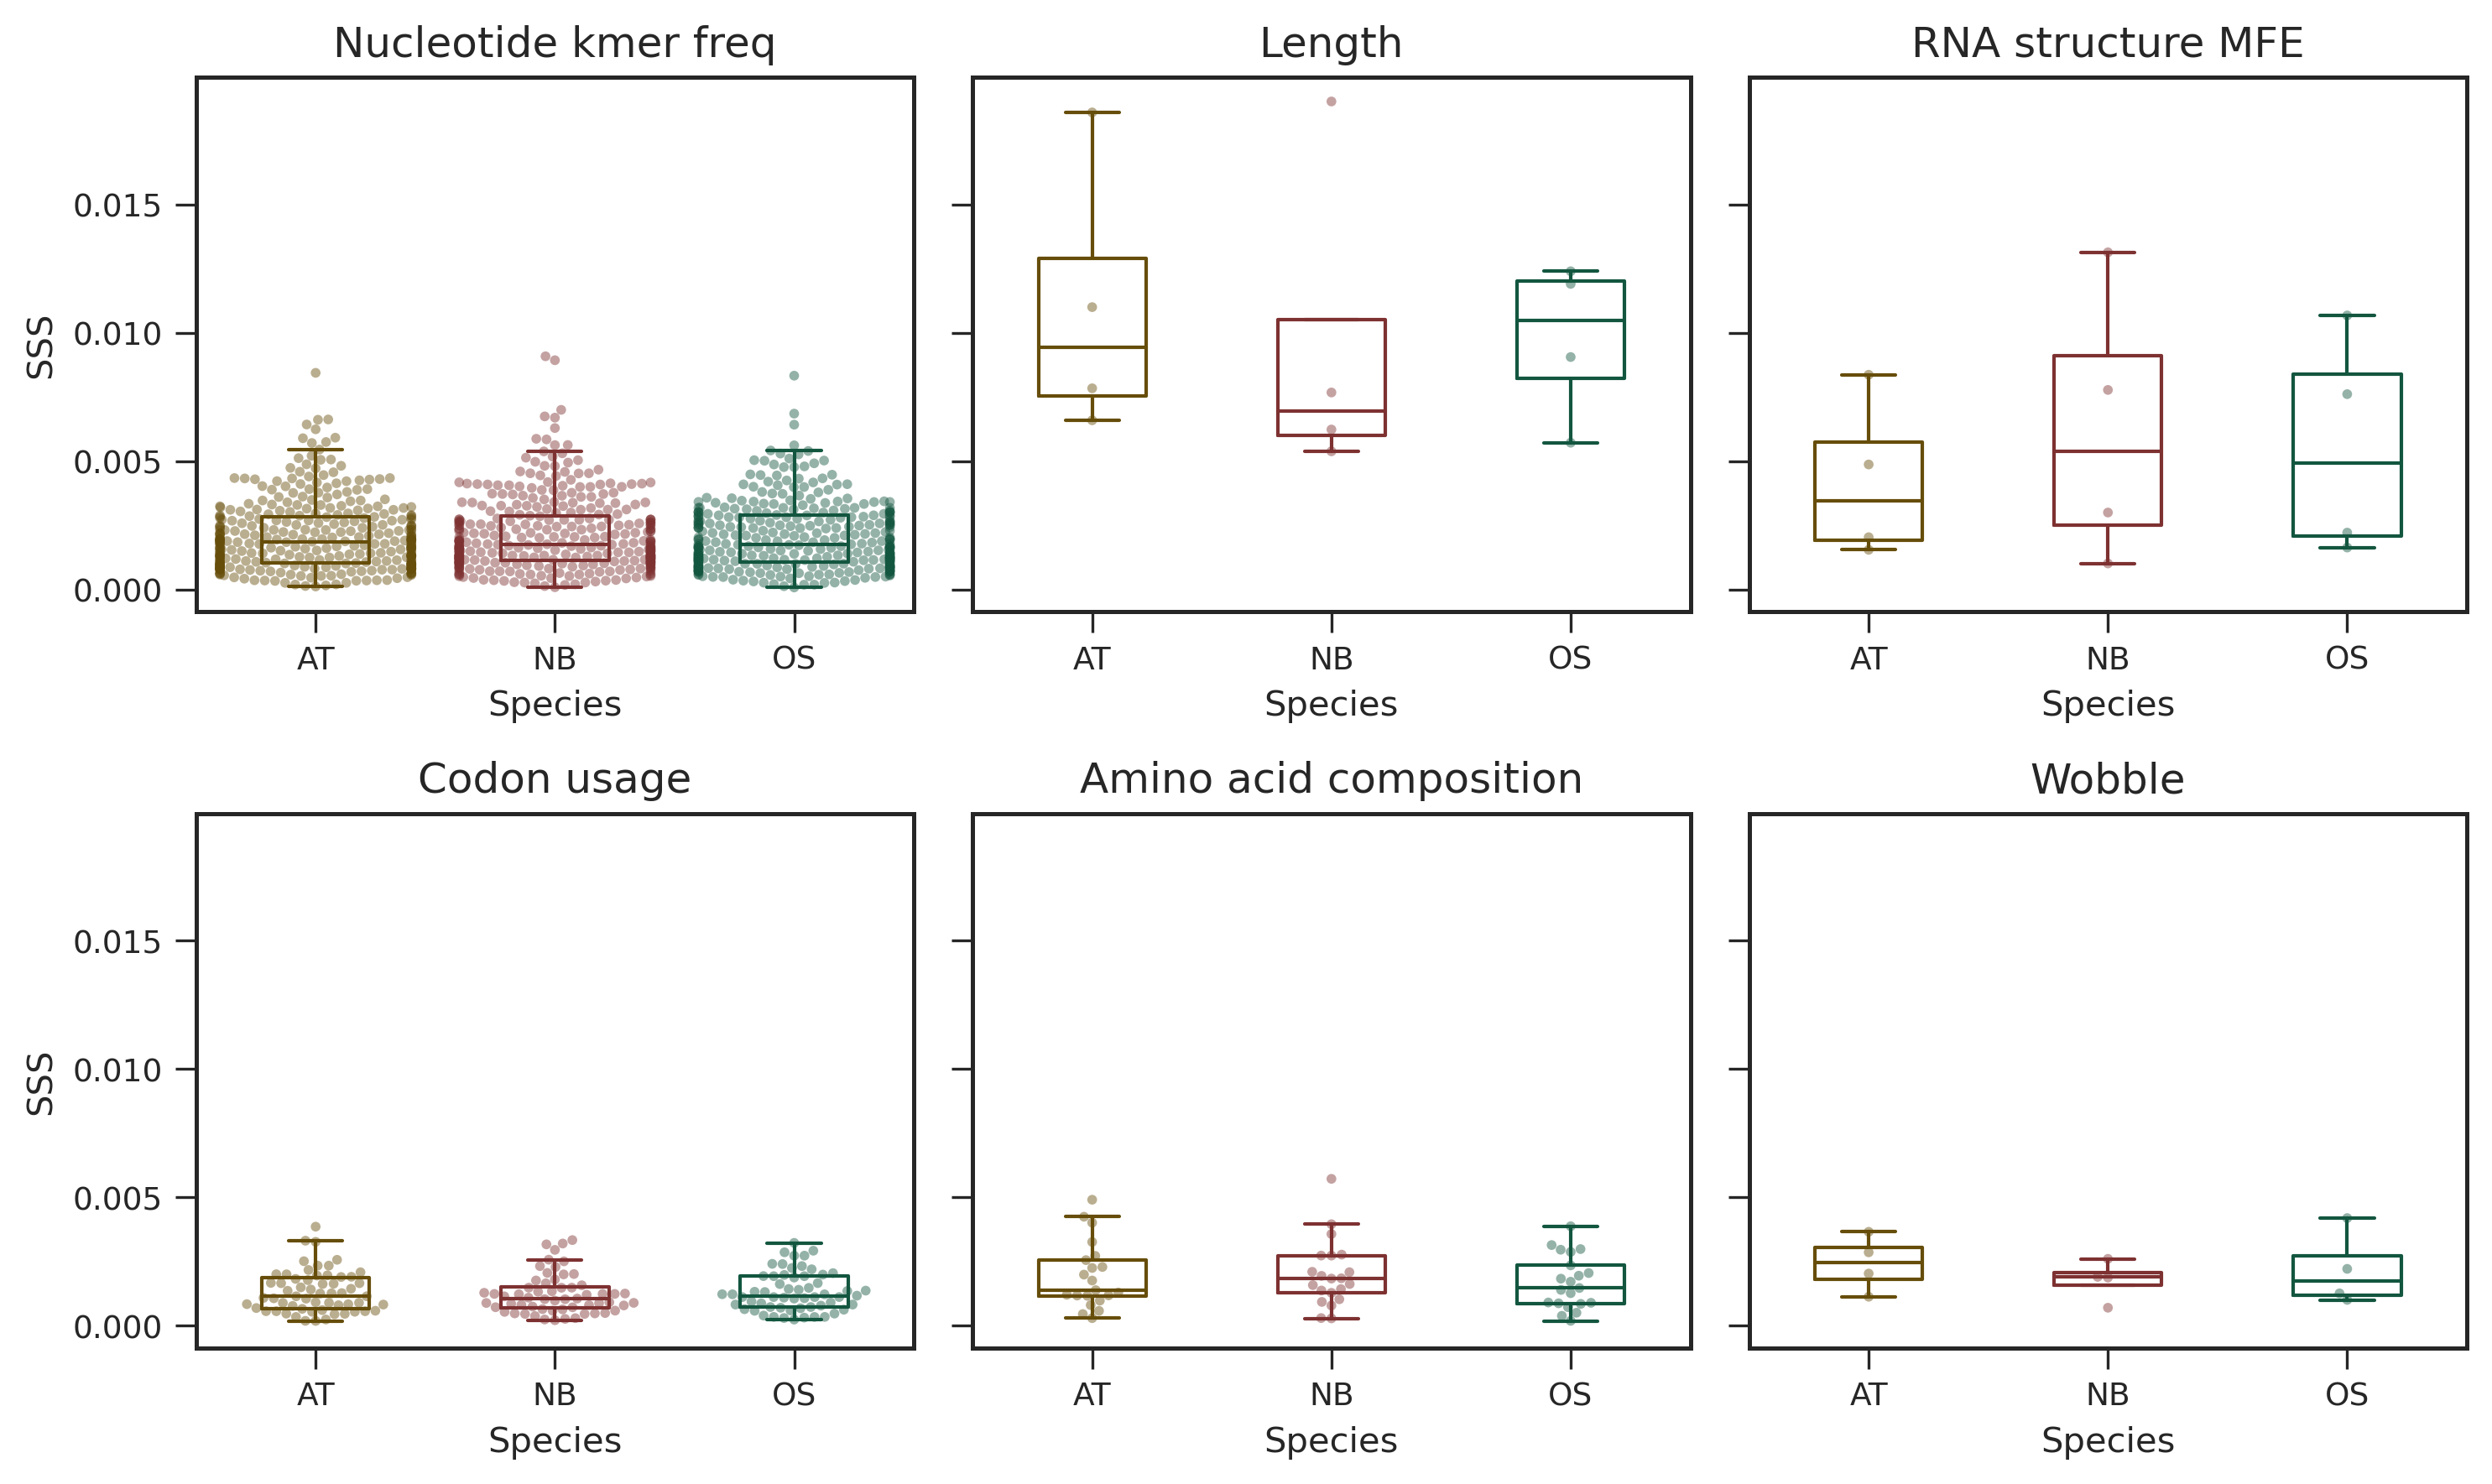

In [10]:
# ============================================
# SSS distribution by feature category
# Boxplot + beeswarm
# ============================================

feature_order = [
    "Nucleotide_kmer_freq", "Length", "RNA_structure_MFE",
    "Codon_usage", "Amino_acid_composition", "Wobble",
]

species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=_PLOT_CFG["dpi"], sharey=True)

for ax, feature_type in zip(axes.flat, feature_order):
    temp = sss_long.loc[sss_long["Feature_type"] == feature_type]

    sns.boxplot(
        data=temp, x="Species", y="SSS", order=species_order, palette=palette,
        width=0.45, showfliers=False, fill=False, linewidth=1, ax=ax,
    )

    sns.swarmplot(
        data=temp, x="Species", y="SSS", order=species_order, palette=palette,
        size=2.8, alpha=0.45, linewidth=0, ax=ax,
    )

    ax.set_title(feature_type.replace("_", " "))
    format_axis(ax, xlabel=None, ylabel="SSS" if ax in axes[:, 0] else None)

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# Species-wise percentile ranking
# ============================================

candidate_df["Importance_percentile"] = (
    candidate_df.groupby("Species")["Importance_normalized"].rank(pct=True)
)

candidate_df["SSS_percentile"] = (
    candidate_df.groupby("Species")["SSS"].rank(pct=True)
)

candidate_df["Enrichment"] = np.where(candidate_df["Delta"] > 0, "Enriched", "Depleted")

display(
    candidate_df[
        ["Species", "Feature", "Region", "Feature_type",
         "Importance_normalized", "Importance_percentile",
         "SSS", "SSS_percentile", "Delta", "Enrichment"]
    ].head()
)

,Species,Feature,Region,Feature_type,Importance_normalized,Importance_percentile,SSS,SSS_percentile,Delta,Enrichment
0,AT,3'UTR.A-freq,3'UTR,Nucleotide_kmer_freq,0.001579,0.359688,0.002228,0.659243,-0.001200,Depleted
1,AT,3'UTR.AA-freq,3'UTR,Nucleotide_kmer_freq,0.003684,0.863029,0.002280,0.672606,0.001081,Enriched
2,AT,3'UTR.AAA-freq,3'UTR,Nucleotide_kmer_freq,0.000789,0.138085,0.002856,0.781737,-0.001981,Depleted
3,AT,3'UTR.AAC-freq,3'UTR,Nucleotide_kmer_freq,0.003684,0.863029,0.002329,0.689310,0.001617,Enriched
4,AT,3'UTR.AAG-freq,3'UTR,Nucleotide_kmer_freq,0.002895,0.743875,0.001495,0.440980,0.000599,Enriched


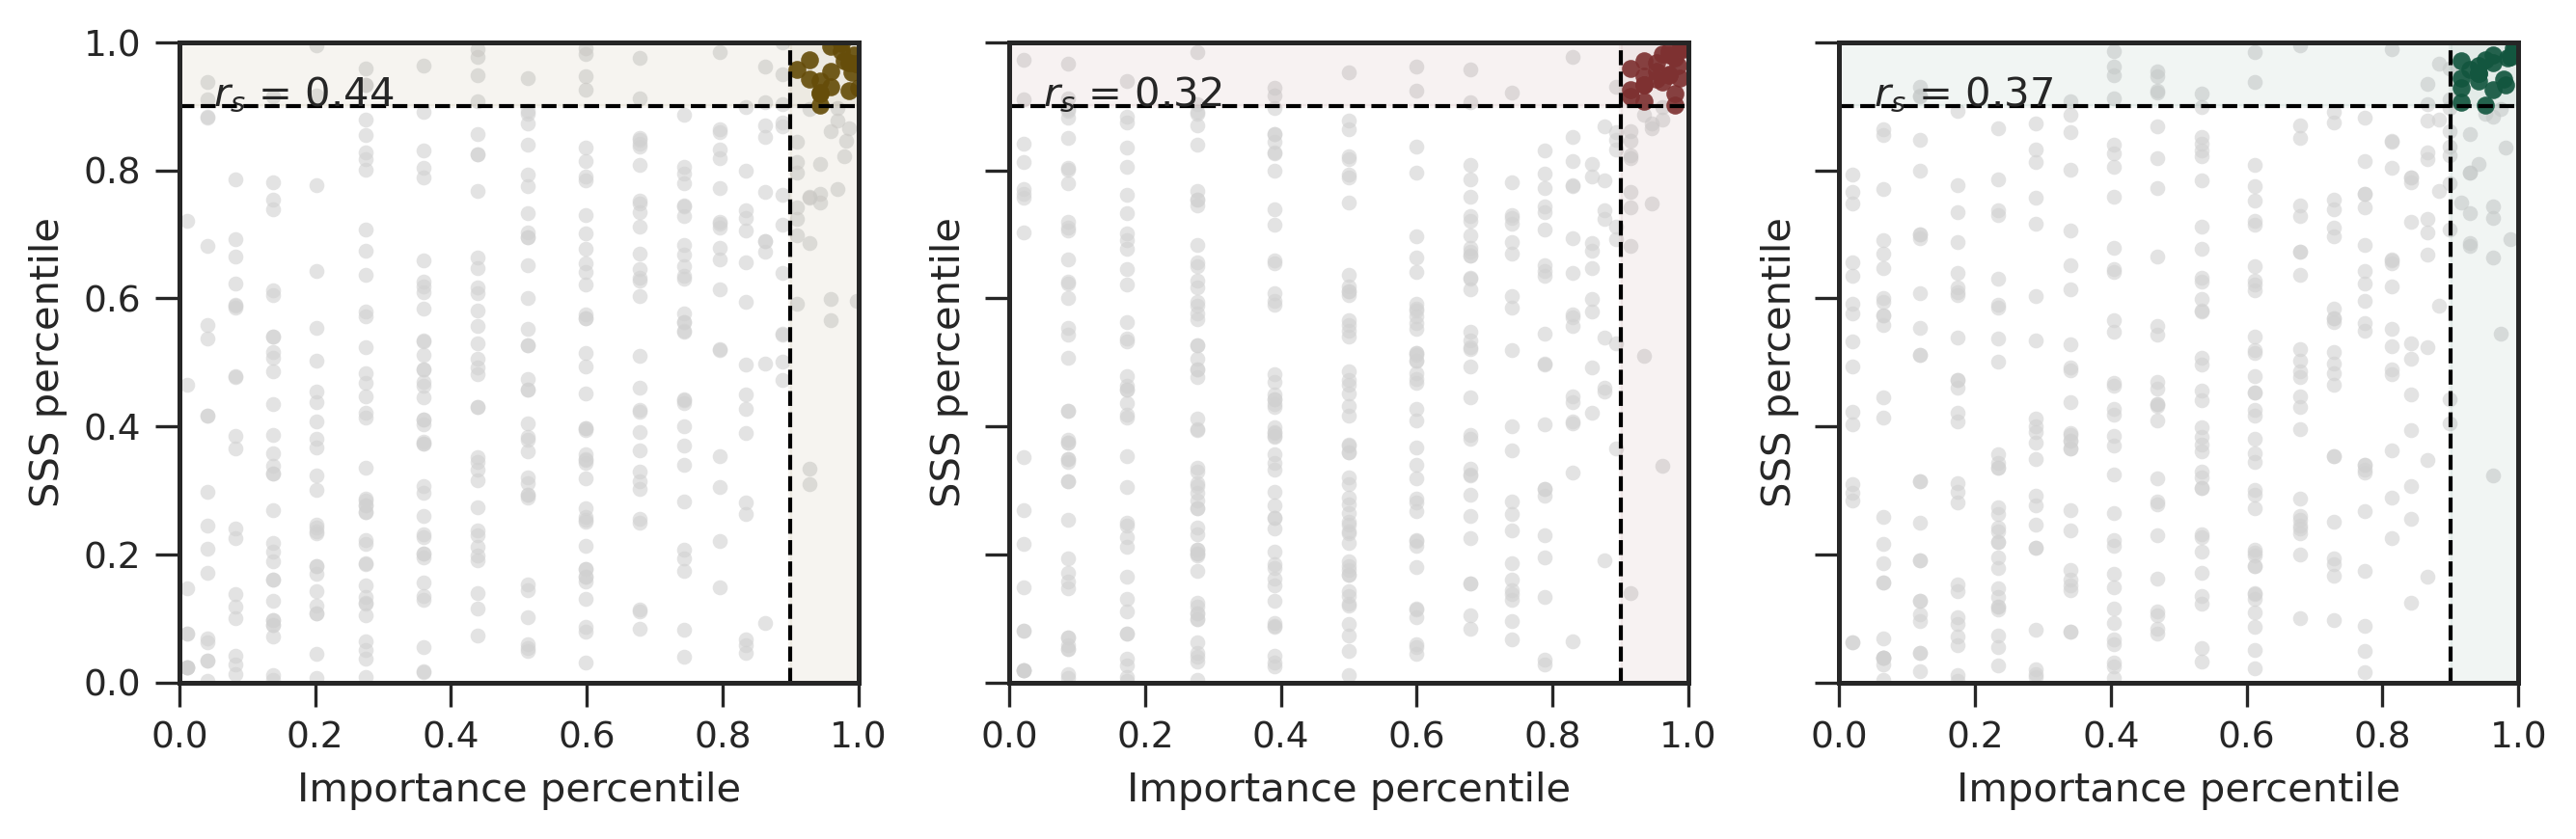

In [12]:
# ============================================
# Importance percentile vs SSS percentile
# Joint feature-selection space
# ============================================

CUTOFF = 0.90

fig, axes = plt.subplots(1, 3, figsize=(9, 3), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):

    species = SPECIES_INFO[species_key]["label"]
    color = SPECIES_INFO[species_key]["color"]

    temp = (
        candidate_df.loc[candidate_df["Species"] == species]
        .dropna(subset=["Importance_percentile", "SSS_percentile"])
        .copy()
    )

    rho, p = stats.spearmanr(
        temp["Importance_percentile"],
        temp["SSS_percentile"],
    )

    keep = (
        (temp["Importance_percentile"] >= CUTOFF) &
        (temp["SSS_percentile"] >= CUTOFF)
    )

    ax.scatter(
        temp["Importance_percentile"],
        temp["SSS_percentile"],
        s=14,
        color="0.82",
        alpha=0.6,
        linewidth=0,
    )

    ax.scatter(
        temp.loc[keep, "Importance_percentile"],
        temp.loc[keep, "SSS_percentile"],
        s=20,
        color=color,
        alpha=0.9,
        linewidth=0,
    )

    ax.axvline(CUTOFF, color="black", ls="--", lw=1)
    ax.axhline(CUTOFF, color="black", ls="--", lw=1)

    ax.axvspan(CUTOFF, 1, color=color, alpha=0.06)
    ax.axhspan(CUTOFF, 1, color=color, alpha=0.06)

    ax.text(
        0.05,
        0.95,
        rf"$r_s$ = {rho:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )

    format_axis(
        ax,
        xlabel="Importance percentile",
        ylabel="SSS percentile",
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

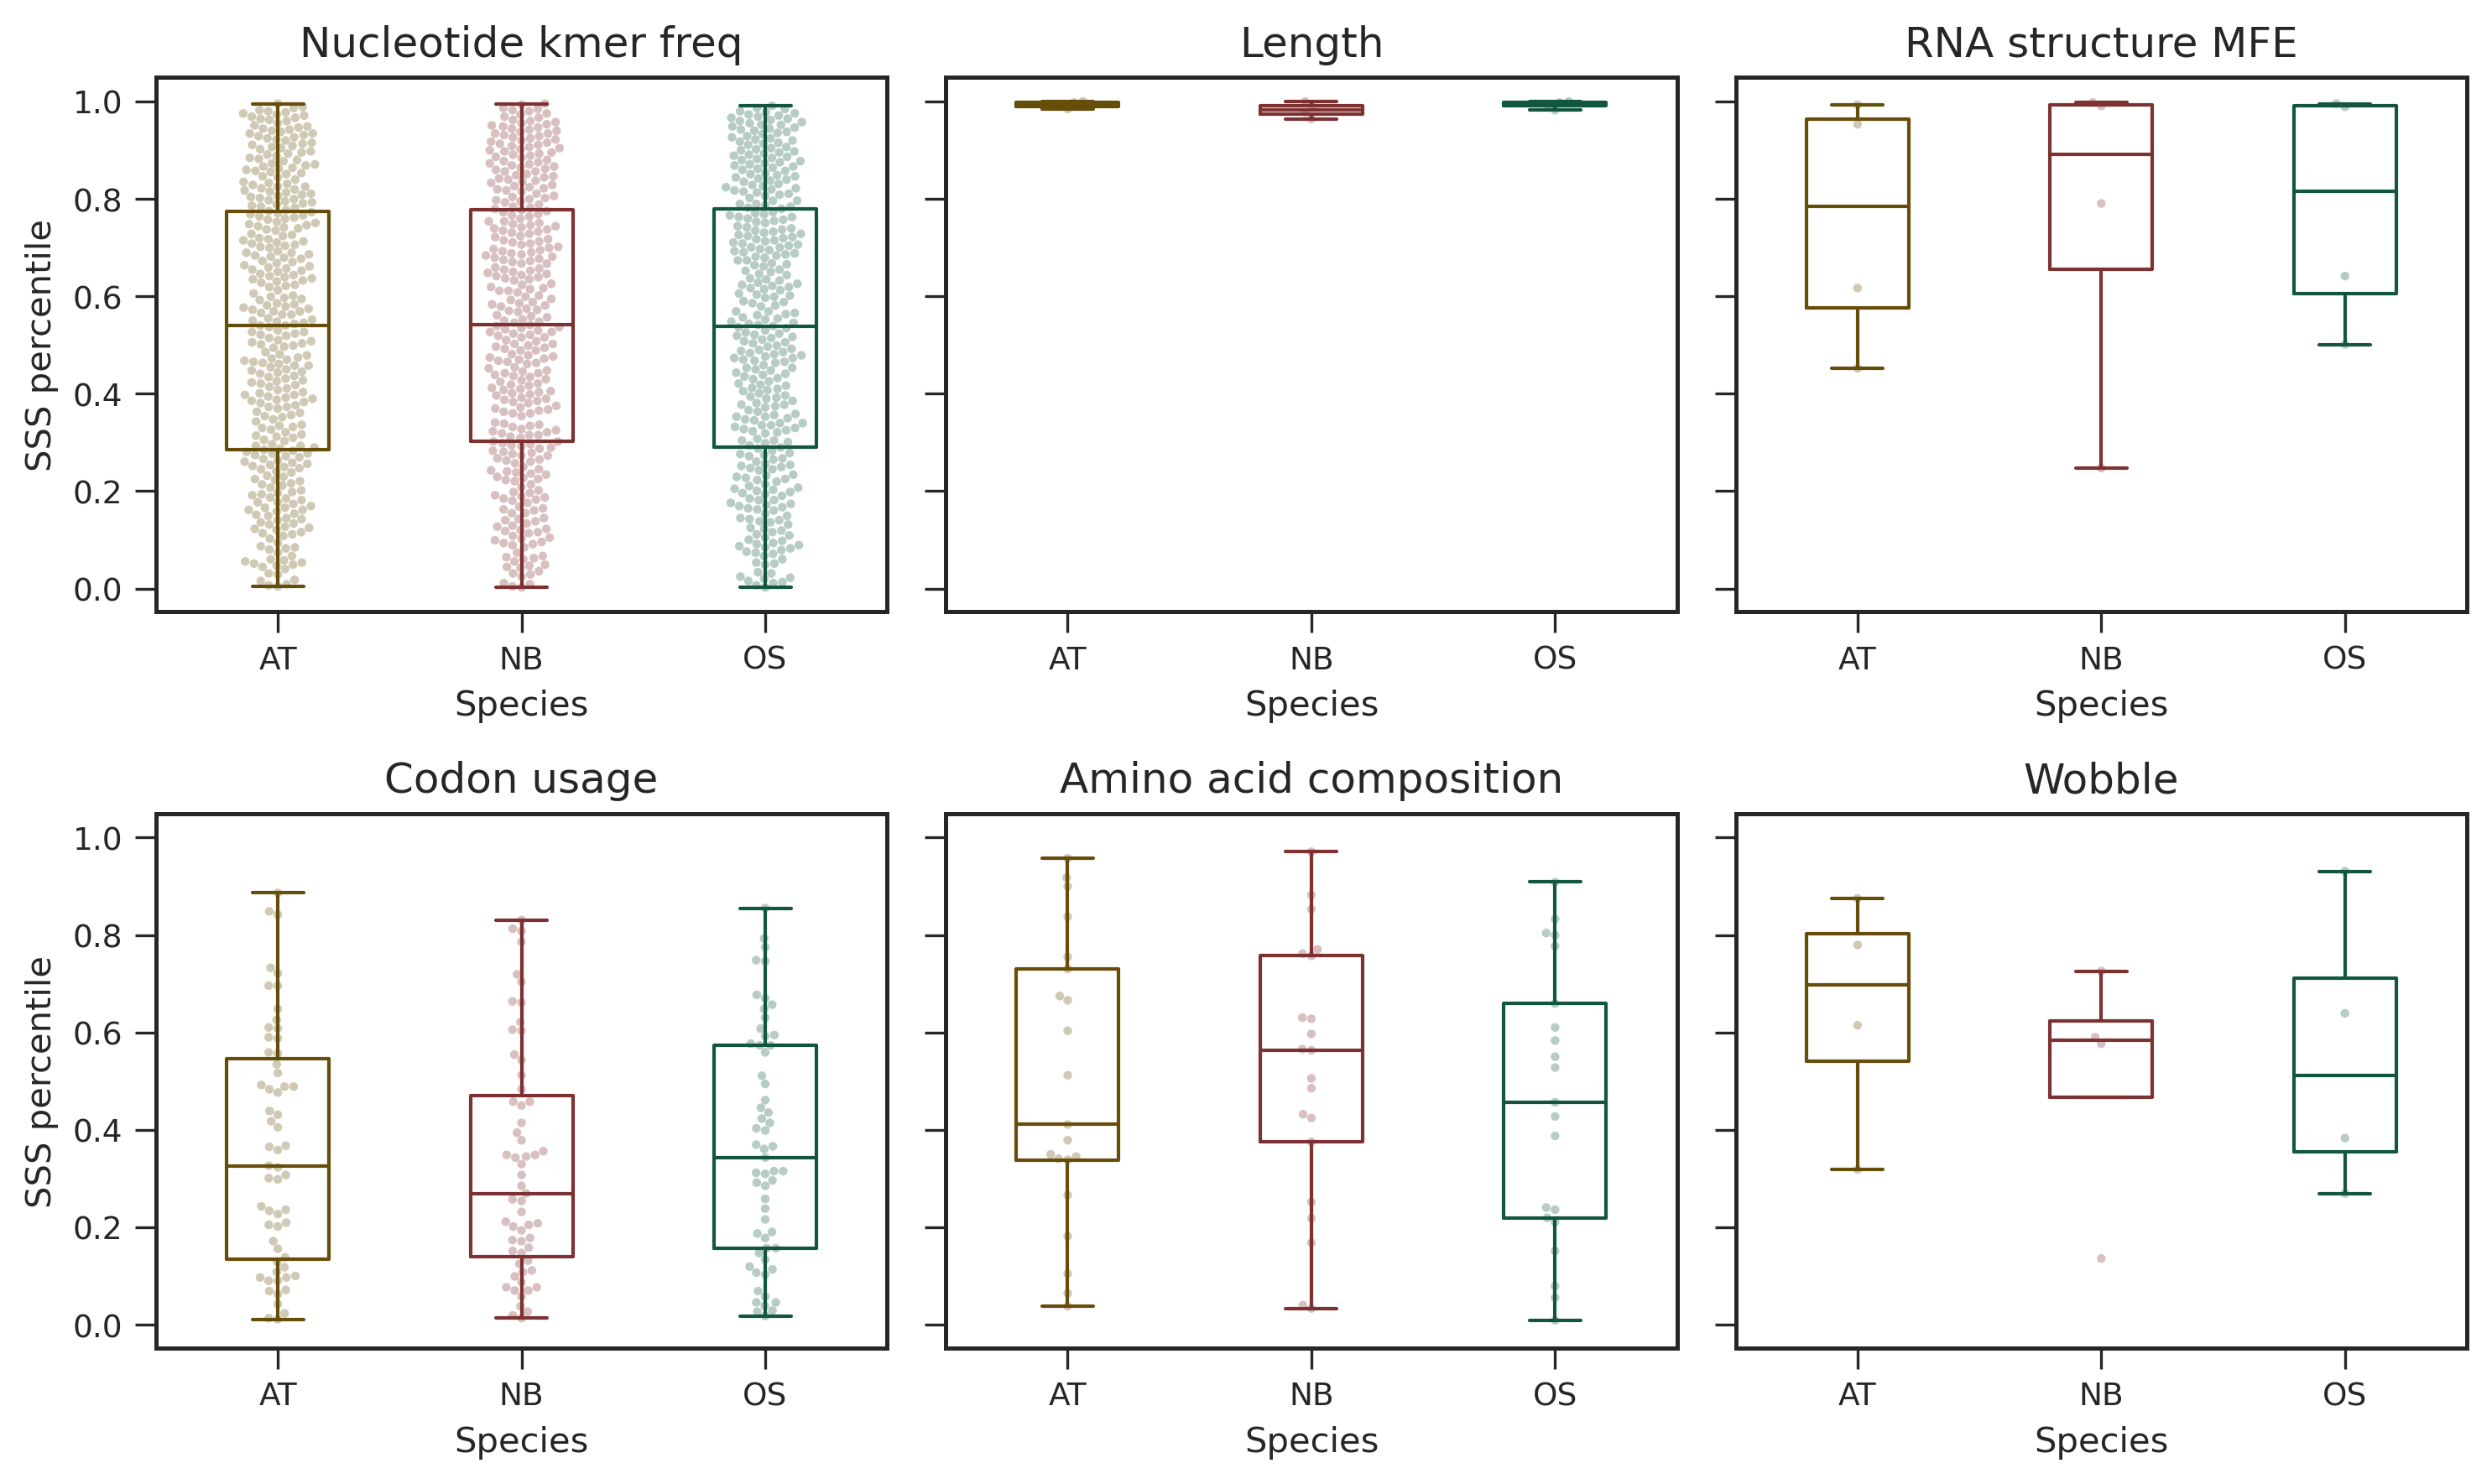

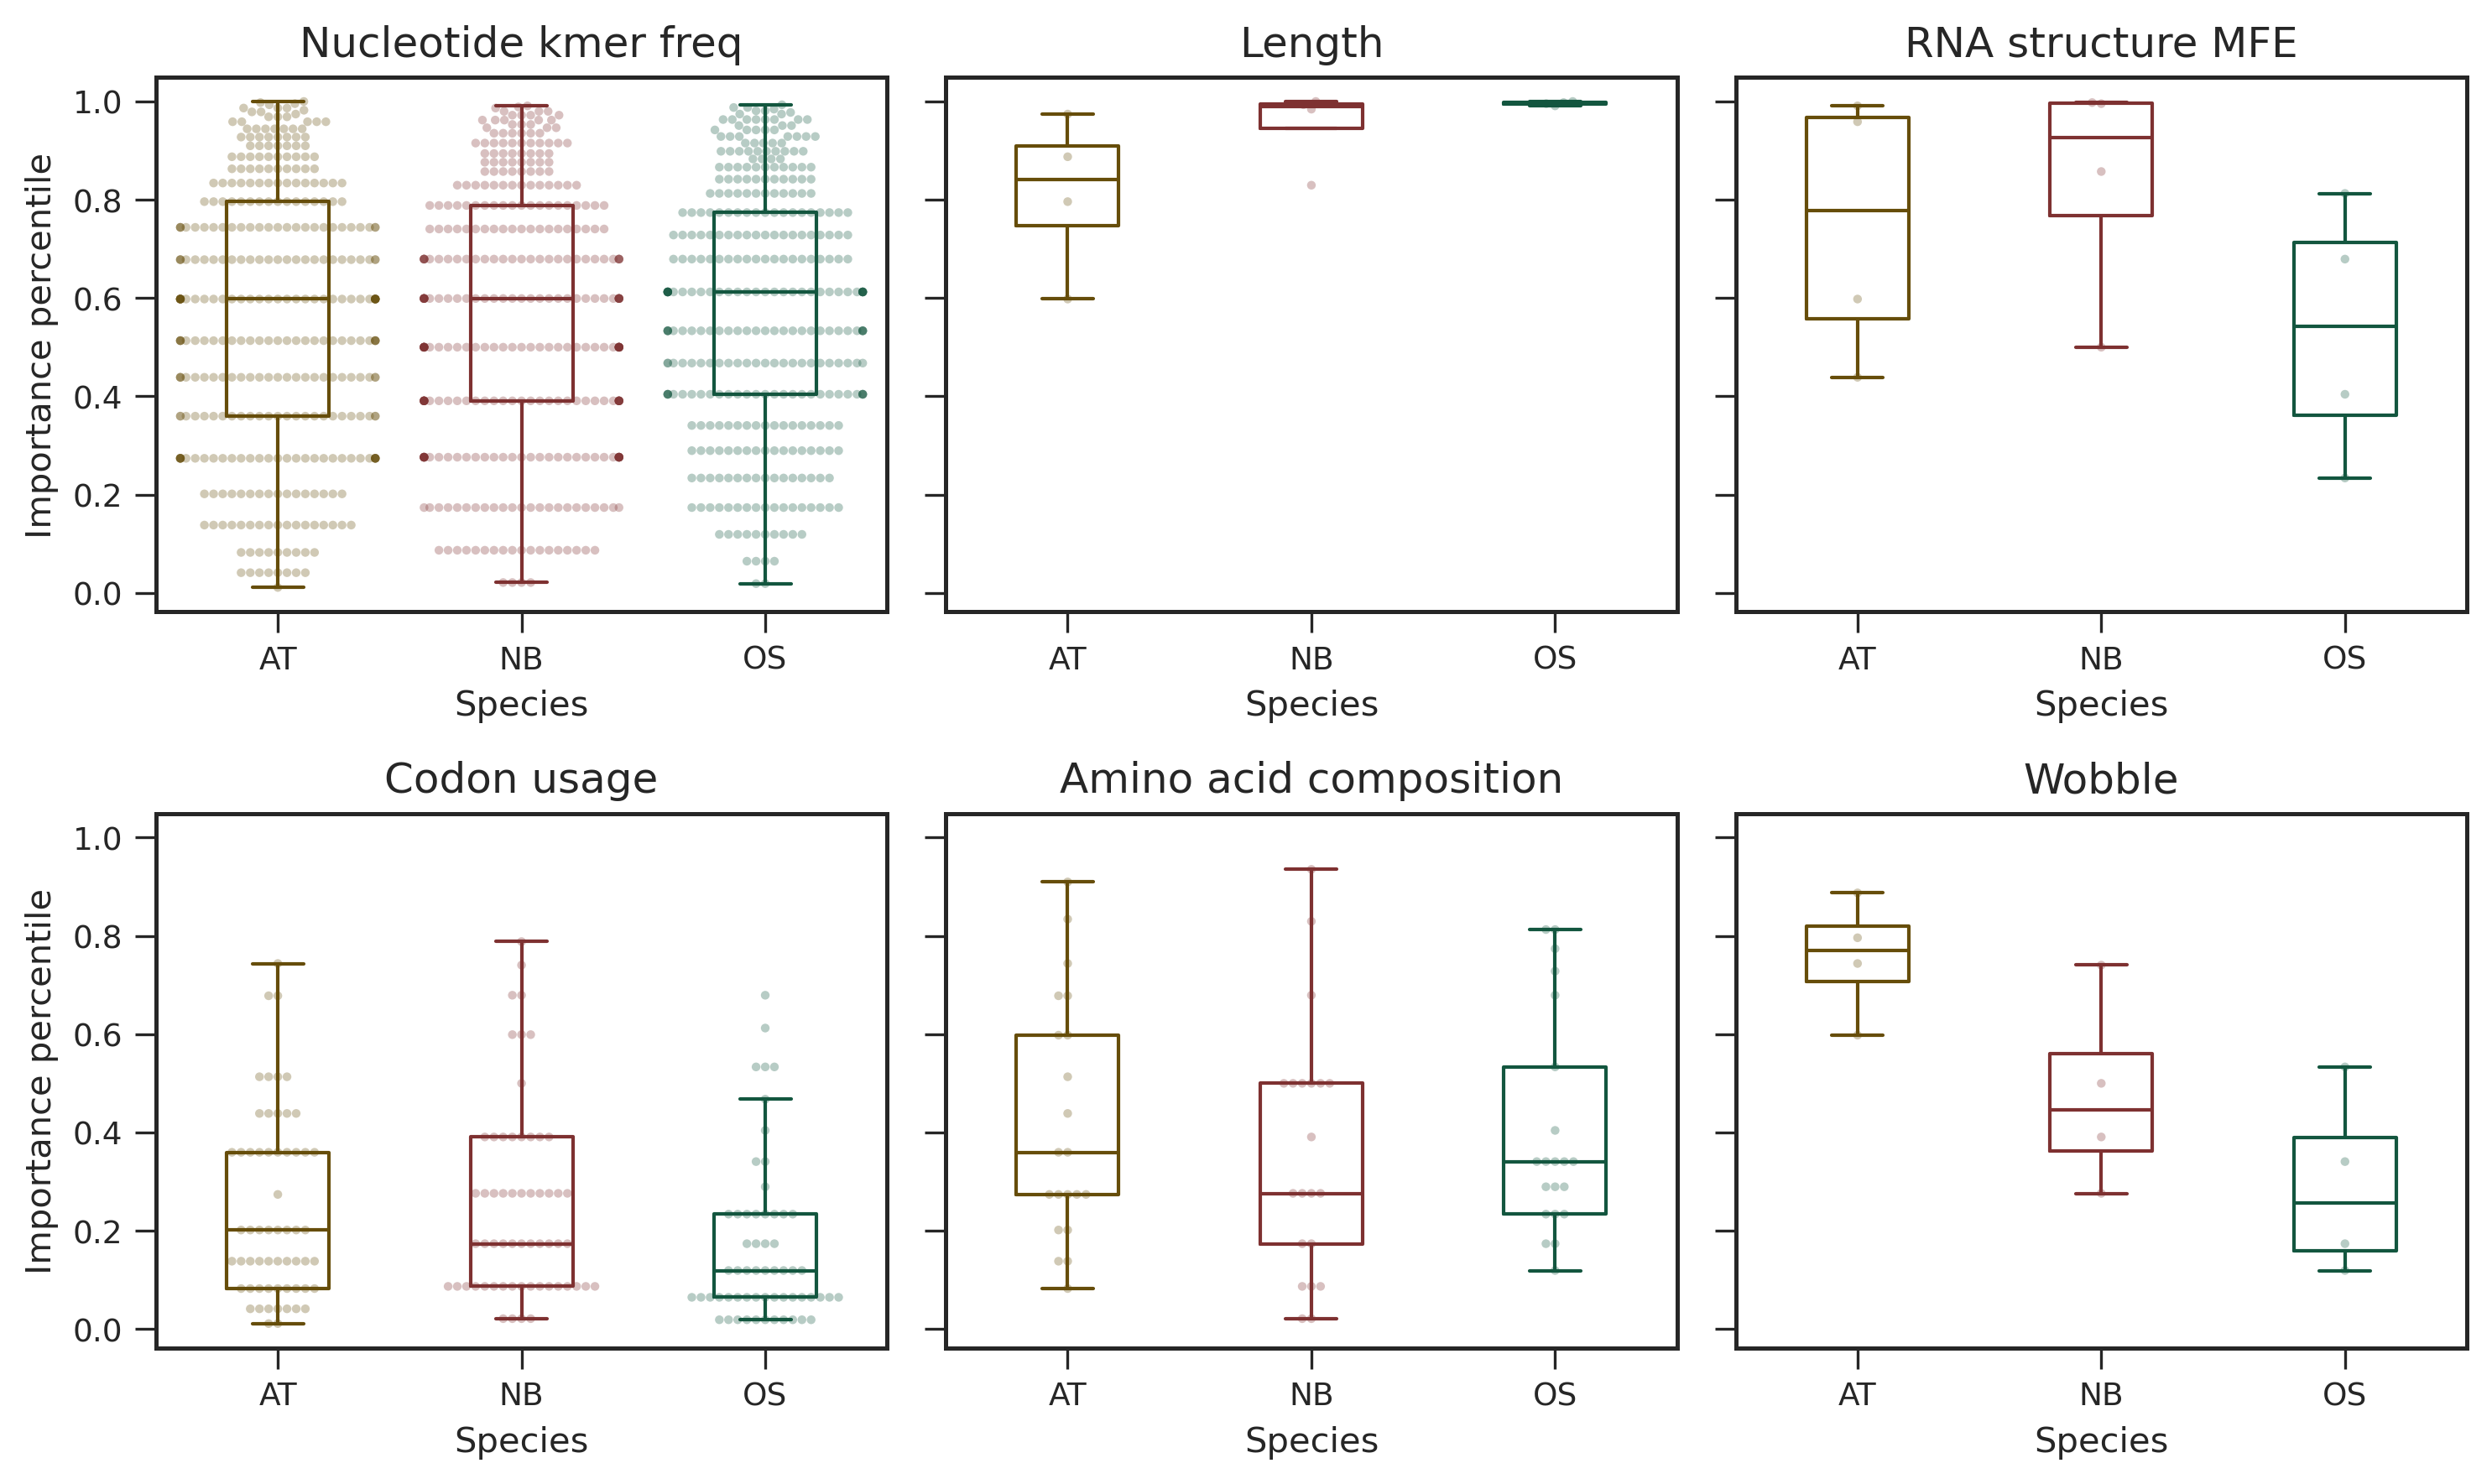

,Feature_type,Species,N_features,N_SSS_p90,N_importance_p90,N_joint_p90
0,Amino_acid_composition,AT,21,2,1,1
1,Amino_acid_composition,NB,21,1,1,1
2,Amino_acid_composition,OS,21,1,0,0
3,Codon_usage,AT,59,0,0,0
4,Codon_usage,NB,59,0,0,0
5,Codon_usage,OS,59,0,0,0
6,Length,AT,4,4,1,1
7,Length,NB,4,4,3,3
8,Length,OS,4,4,4,4
9,Nucleotide_kmer_freq,AT,345,37,41,15


In [13]:
# ============================================
# Global percentile ranking by feature category
# SSS percentile + importance percentile
# ============================================

feature_order = [
    "Nucleotide_kmer_freq", "Length", "RNA_structure_MFE",
    "Codon_usage", "Amino_acid_composition", "Wobble",
]
species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}
plot_df = candidate_df.loc[candidate_df["Feature_type"].isin(feature_order)].copy()

def plot_percentile_grid(y, ylabel):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6), dpi=_PLOT_CFG["dpi"], sharey=True)

    for ax, feature_type in zip(axes.flat, feature_order):
        temp = plot_df.loc[plot_df["Feature_type"] == feature_type]

        sns.boxplot(
            data=temp, x="Species", y=y, order=species_order, palette=palette,
            width=0.42, showfliers=False, fill=False, linewidth=1, ax=ax,
        )
        sns.swarmplot(
            data=temp, x="Species", y=y, order=species_order, palette=palette,
            size=2.5, alpha=0.30, linewidth=0, ax=ax,
        )

        # ax.axhline(0.90, color="black", ls="--", lw=1)
        ax.set_title(feature_type.replace("_", " "))
        format_axis(ax, xlabel=None, ylabel=ylabel if ax in axes[:, 0] else None)

    plt.tight_layout()
    plt.show()

plot_percentile_grid("SSS_percentile", "SSS percentile")
plot_percentile_grid("Importance_percentile", "Importance percentile")

# --------------------------------------------
# Features passing both global 0.90 cutoffs
# --------------------------------------------

CUTOFF = 0.90
plot_df["Pass_joint"] = (
    (plot_df["SSS_percentile"] >= CUTOFF) &
    (plot_df["Importance_percentile"] >= CUTOFF)
)

cutoff_summary_df = (
    plot_df.groupby(["Feature_type", "Species"])
    .agg(
        N_features=("Feature", "size"),
        N_SSS_p90=("SSS_percentile", lambda x: (x >= CUTOFF).sum()),
        N_importance_p90=("Importance_percentile", lambda x: (x >= CUTOFF).sum()),
        N_joint_p90=("Pass_joint", "sum"),
    )
    .reset_index()
)

display(cutoff_summary_df)

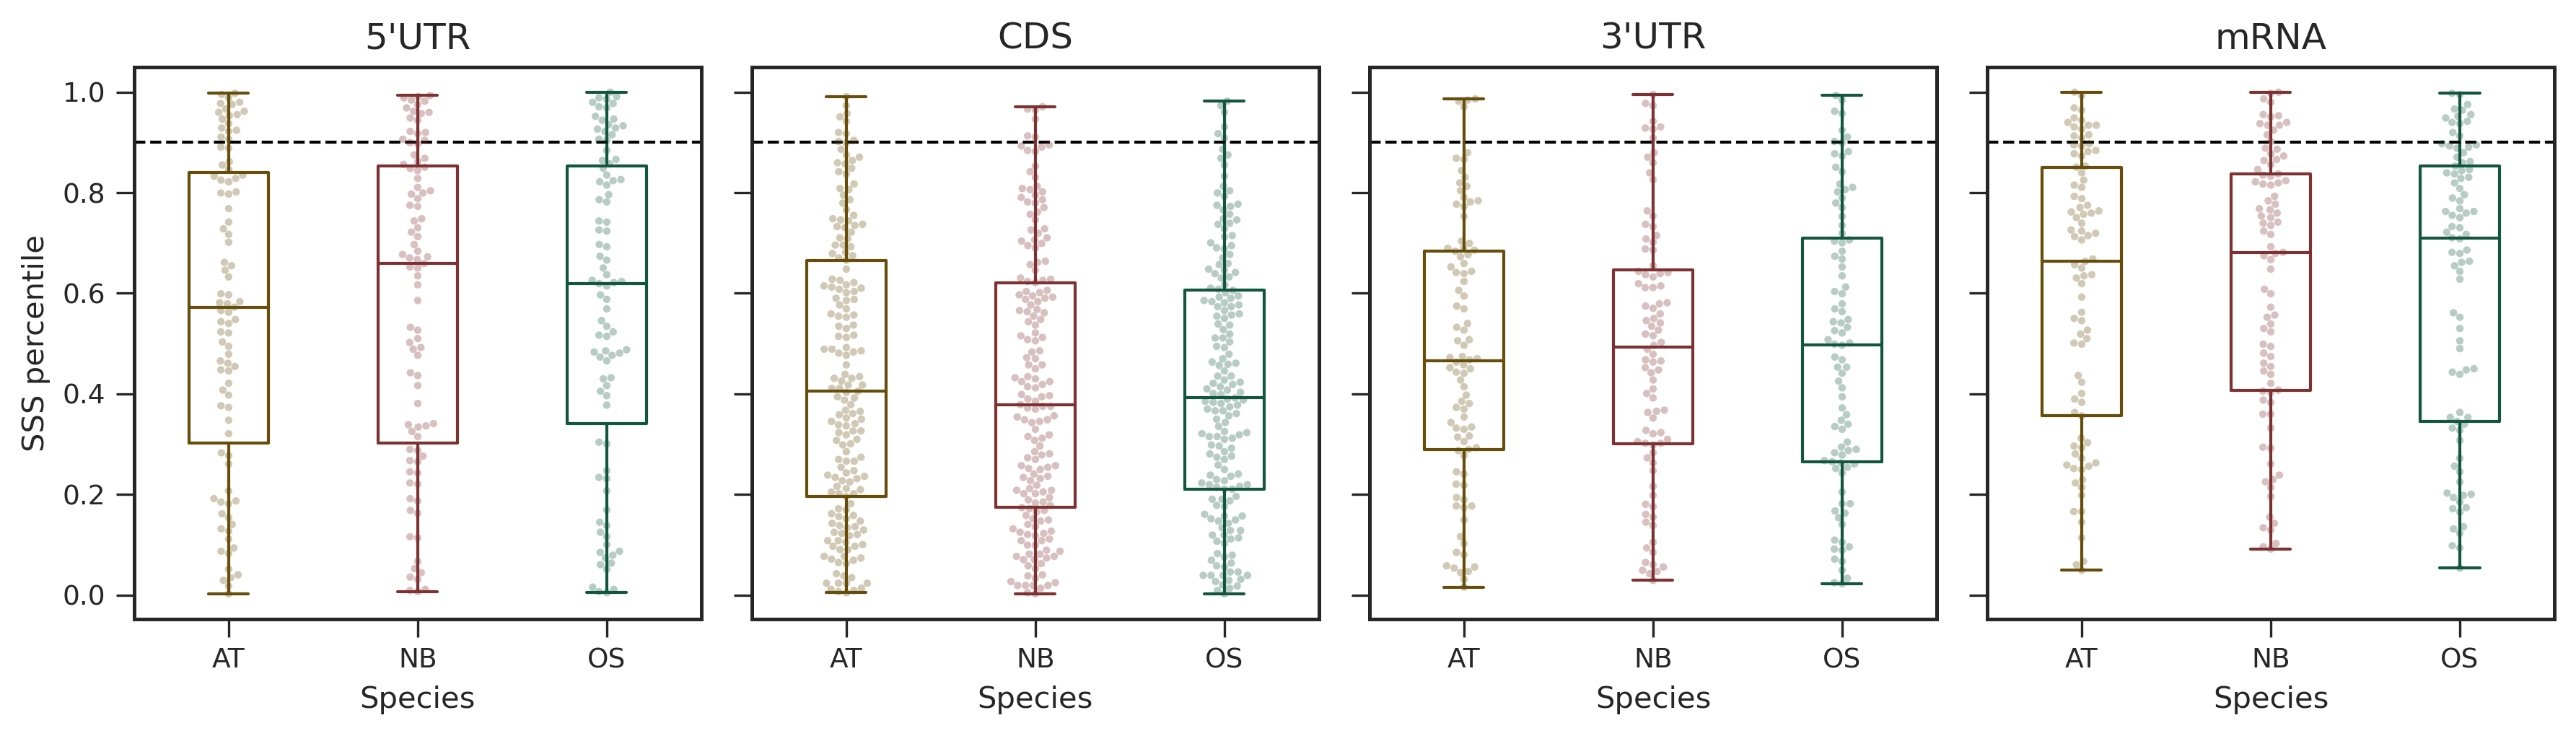

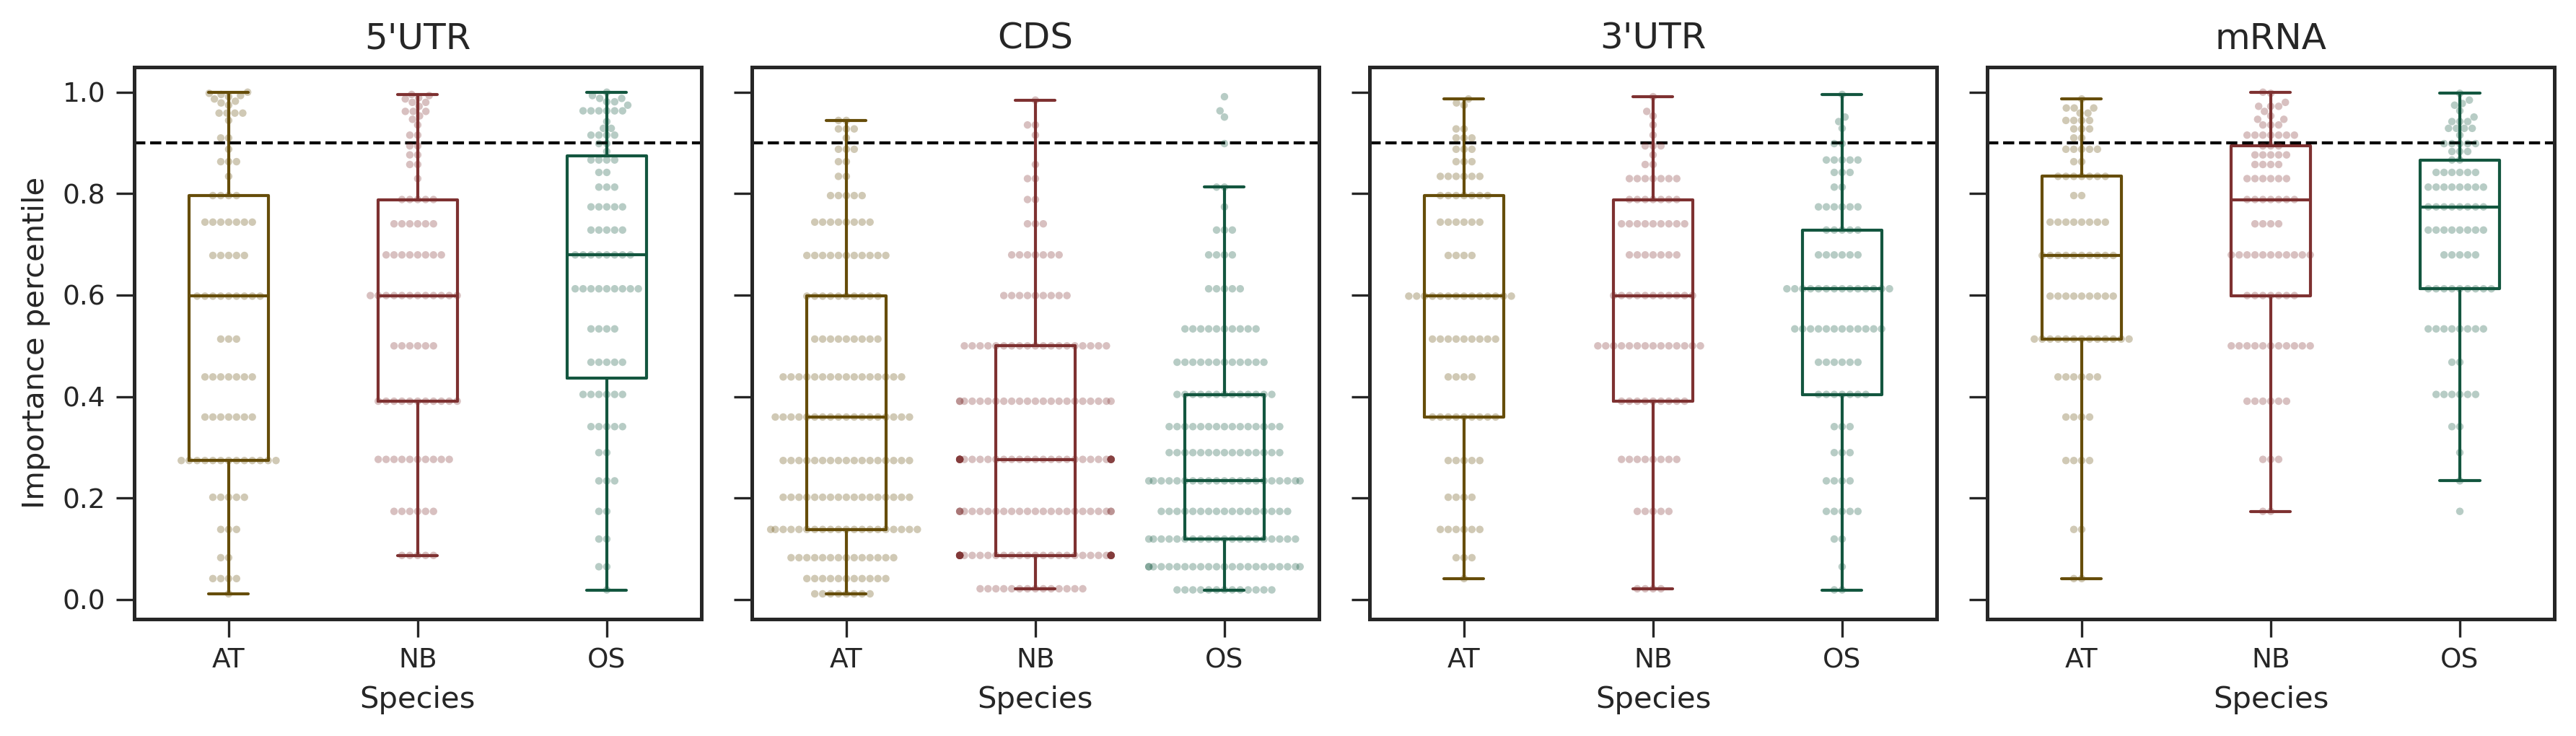

,Region,Species,N_features,N_SSS_p90,N_importance_p90,N_joint_p90
0,3'UTR,AT,92,4,8,2
1,3'UTR,NB,92,8,5,4
2,3'UTR,OS,92,7,4,3
3,5'UTR,AT,91,18,16,8
4,5'UTR,NB,91,17,15,10
5,5'UTR,OS,91,19,20,12
6,CDS,AT,177,9,6,5
7,CDS,NB,177,6,4,3
8,CDS,OS,177,6,3,2
9,mRNA,AT,89,14,15,4


In [14]:
# ============================================
# Global percentile ranking by transcript region
# SSS percentile + importance percentile
# ============================================

region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]
species_order = ["AT", "NB", "OS"]
palette = {SPECIES_INFO[k]["label"]: SPECIES_INFO[k]["color"] for k in SPECIES}
plot_df = candidate_df.loc[candidate_df["Region"].isin(region_order)].copy()

def plot_region_percentile(y, ylabel):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"], sharey=True)

    for ax, region in zip(axes, region_order):
        temp = plot_df.loc[plot_df["Region"] == region]

        sns.boxplot(
            data=temp, x="Species", y=y, order=species_order, palette=palette,
            width=0.42, showfliers=False, fill=False, linewidth=1, ax=ax,
        )
        sns.swarmplot(
            data=temp, x="Species", y=y, order=species_order, palette=palette,
            size=2.5, alpha=0.30, linewidth=0, ax=ax,
        )

        ax.axhline(0.90, color="black", ls="--", lw=1)
        ax.set_title(region)
        format_axis(ax, xlabel=None, ylabel=ylabel if ax is axes[0] else None)

    plt.tight_layout()
    plt.show()

plot_region_percentile("SSS_percentile", "SSS percentile")
plot_region_percentile("Importance_percentile", "Importance percentile")

# --------------------------------------------
# Features passing both global 0.90 cutoffs
# --------------------------------------------

CUTOFF = 0.90
plot_df["Pass_joint"] = (
    (plot_df["SSS_percentile"] >= CUTOFF) &
    (plot_df["Importance_percentile"] >= CUTOFF)
)

region_cutoff_summary_df = (
    plot_df.groupby(["Region", "Species"])
    .agg(
        N_features=("Feature", "size"),
        N_SSS_p90=("SSS_percentile", lambda x: (x >= CUTOFF).sum()),
        N_importance_p90=("Importance_percentile", lambda x: (x >= CUTOFF).sum()),
        N_joint_p90=("Pass_joint", "sum"),
    )
    .reset_index()
)

display(region_cutoff_summary_df)

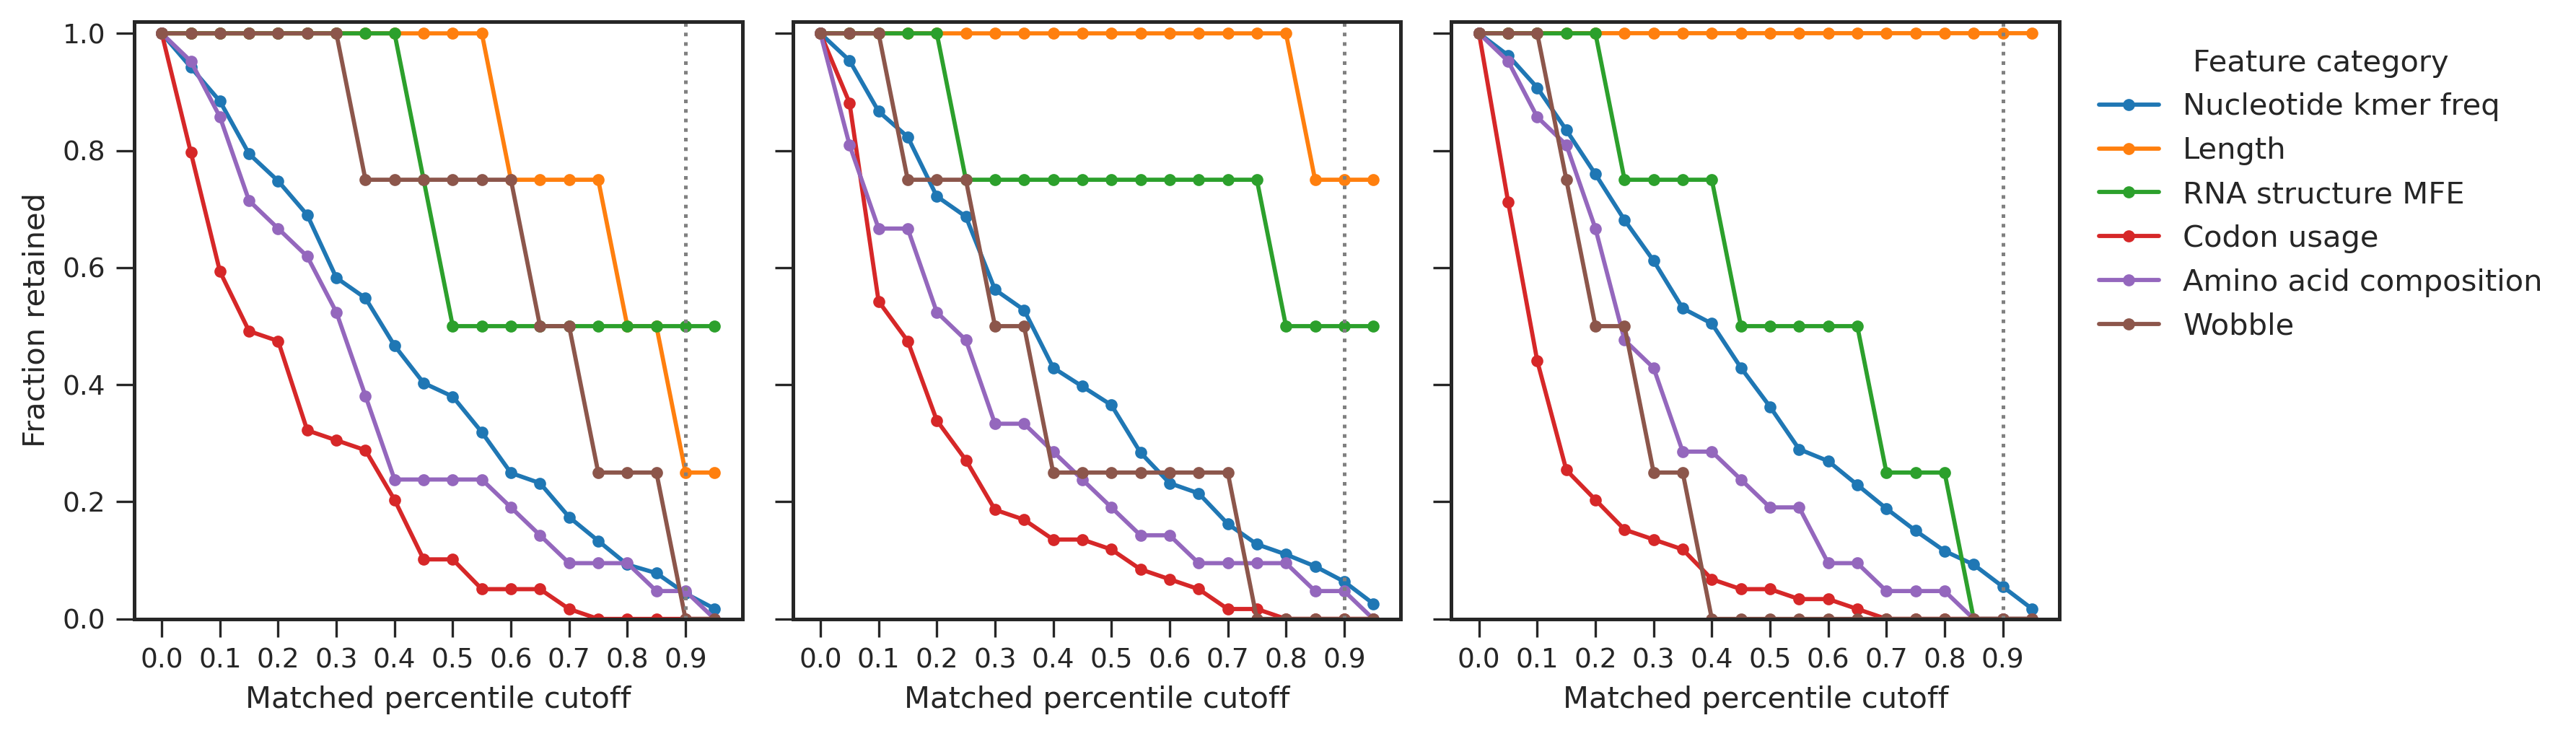

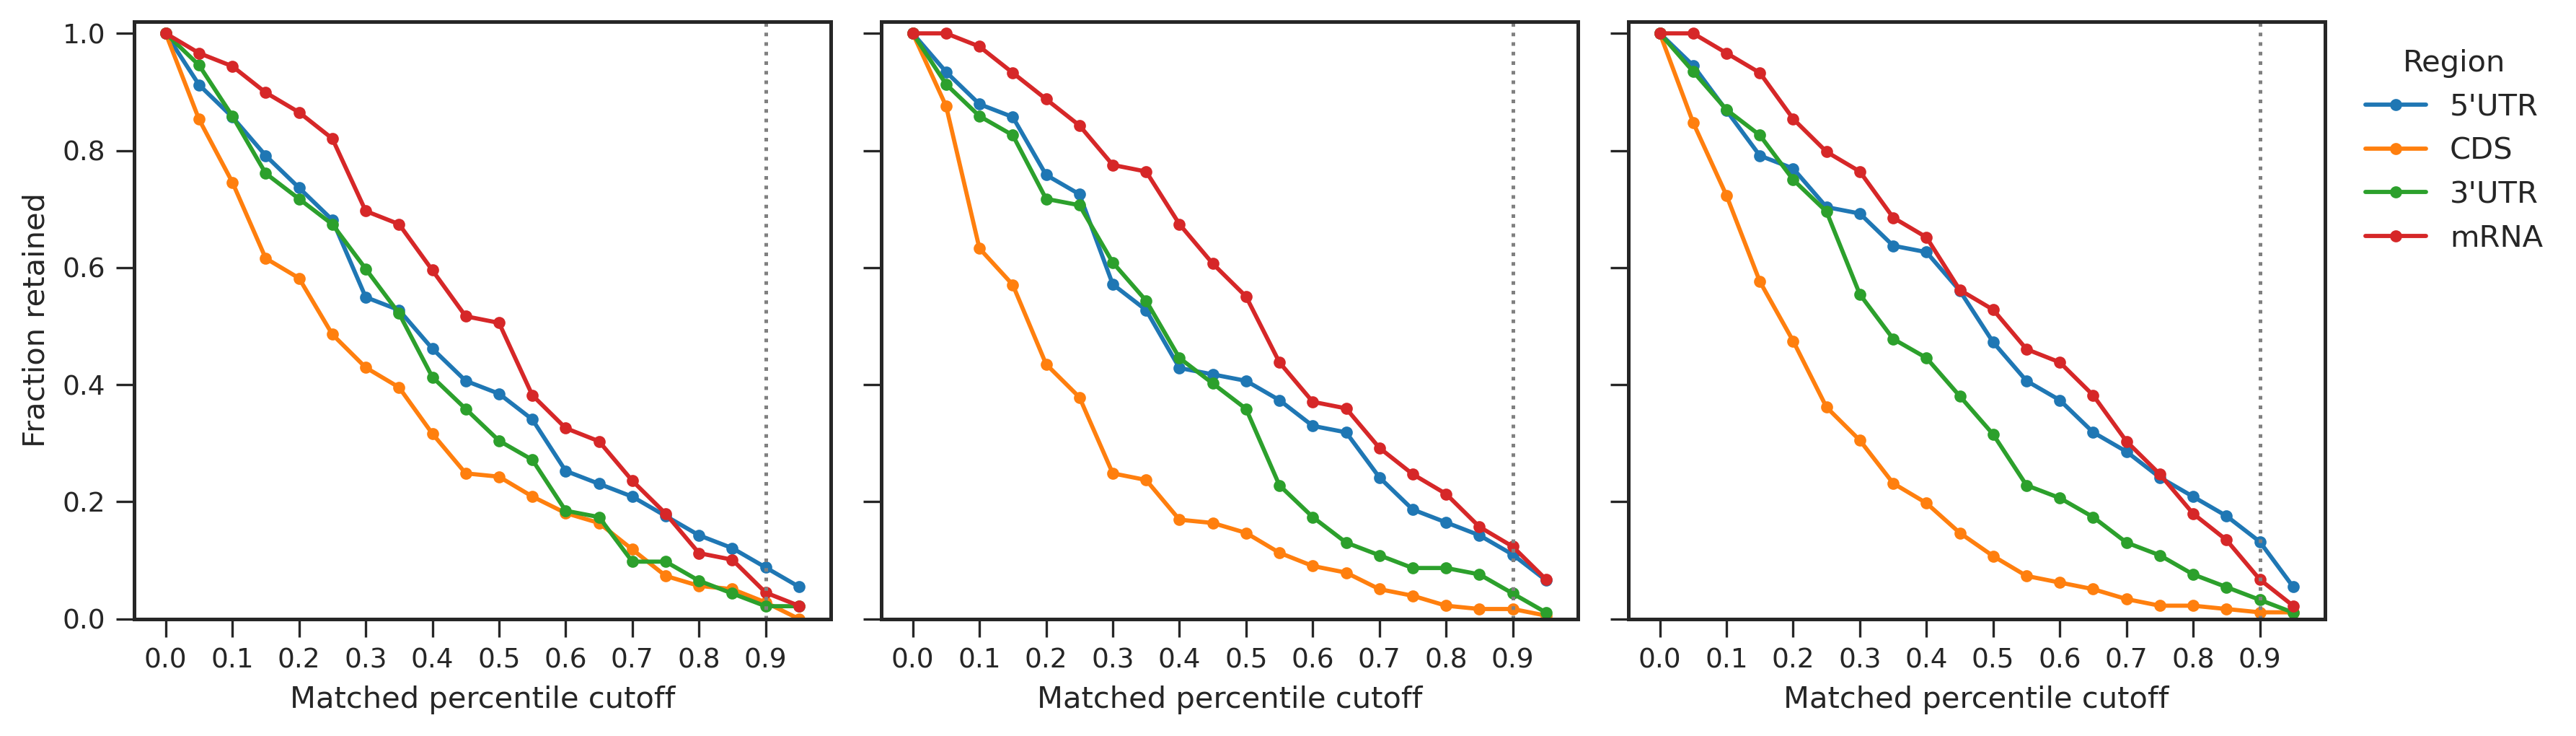

In [15]:
# ============================================
# Biological composition across global cutoffs
# Feature category + transcript region
# ============================================

cutoffs = np.arange(0.00, 1.00, 0.05)
feature_order = ["Nucleotide_kmer_freq", "Length", "RNA_structure_MFE",
                 "Codon_usage", "Amino_acid_composition", "Wobble"]
region_order = ["5'UTR", "CDS", "3'UTR", "mRNA"]

def retention_by_group(group_col, group_order):
    rows = []
    for species in ["AT", "NB", "OS"]:
        sp = candidate_df.loc[candidate_df["Species"] == species]
        for group in group_order:
            temp = sp.loc[sp[group_col] == group]
            for cutoff in cutoffs:
                keep = (temp["Importance_percentile"] >= cutoff) & (temp["SSS_percentile"] >= cutoff)
                rows.append({"Species": species, "Group": group, "Cutoff": cutoff,
                             "N_total": len(temp), "N_retained": keep.sum(),
                             "Fraction_retained": keep.mean() if len(temp) else np.nan})
    return pd.DataFrame(rows)

feature_retention_df = retention_by_group("Feature_type", feature_order)
region_retention_df = retention_by_group("Region", region_order)

# --------------------------------------------
# Feature-category retention
# --------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = feature_retention_df.loc[feature_retention_df["Species"] == species]

    for group in feature_order:
        g = temp.loc[temp["Group"] == group]
        ax.plot(g["Cutoff"], g["Fraction_retained"], marker="o", ms=3, lw=1.4,
                label=group.replace("_", " "))

    ax.axvline(0.90, color="0.5", ls=":", lw=1.2)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    ax.set_ylim(0, 1.02)
    format_axis(ax, xlabel="Matched percentile cutoff",
                ylabel="Fraction retained" if ax is axes[0] else None)

axes[-1].legend(title="Feature category", frameon=False,
                loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# --------------------------------------------
# Transcript-region retention
# --------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), dpi=_PLOT_CFG["dpi"], sharex=True, sharey=True)

for ax, species_key in zip(axes, SPECIES):
    species = SPECIES_INFO[species_key]["label"]
    temp = region_retention_df.loc[region_retention_df["Species"] == species]

    for region in region_order:
        g = temp.loc[temp["Group"] == region]
        ax.plot(g["Cutoff"], g["Fraction_retained"], marker="o", ms=3, lw=1.4, label=region)

    ax.axvline(0.90, color="0.5", ls=":", lw=1.2)
    ax.set_xticks(np.arange(0, 1.0, 0.1))
    ax.set_ylim(0, 1.02)
    format_axis(ax, xlabel="Matched percentile cutoff",
                ylabel="Fraction retained" if ax is axes[0] else None)

axes[-1].legend(title="Region", frameon=False,
                loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Feature-category retention summary
# Global matched cutoff = 0.90
# ============================================

CUTOFF = 0.90

category_check_df = (
    candidate_df.loc[candidate_df["Feature_type"].isin(feature_order)]
    .assign(Pass=lambda x:
        (x["Importance_percentile"] >= CUTOFF) &
        (x["SSS_percentile"] >= CUTOFF)
    )
    .groupby(["Species", "Feature_type"])
    .agg(
        N_total=("Feature", "size"),
        N_retained=("Pass", "sum"),
    )
    .reset_index()
)

category_check_df["Fraction_retained"] = (
    category_check_df["N_retained"] / category_check_df["N_total"]
)

display(category_check_df)

,Species,Feature_type,N_total,N_retained,Fraction_retained
0,AT,Amino_acid_composition,21,1,0.047619
1,AT,Codon_usage,59,0,0.000000
2,AT,Length,4,1,0.250000
3,AT,Nucleotide_kmer_freq,345,15,0.043478
4,AT,RNA_structure_MFE,4,2,0.500000
5,AT,Wobble,4,0,0.000000
6,NB,Amino_acid_composition,21,1,0.047619
7,NB,Codon_usage,59,0,0.000000
8,NB,Length,4,3,0.750000
9,NB,Nucleotide_kmer_freq,345,22,0.063768


In [17]:
# ============================================
# Matched threshold path
# Importance cutoff = SSS cutoff
# ============================================

cutoffs = np.arange(0.00, 1.00, 0.05)
threshold_sets, rows = {}, []

for species in ["AT", "NB", "OS"]:
    for cutoff in cutoffs:
        features = set(candidate_df.loc[
            (candidate_df["Species"] == species) &
            (candidate_df["Importance_percentile"] >= cutoff) &
            (candidate_df["SSS_percentile"] >= cutoff),
            "Feature"
        ])

        threshold_sets[(species, cutoff)] = features
        rows.append({"Species": species, "Cutoff": cutoff, "N_features": len(features)})

threshold_path_df = pd.DataFrame(rows)

print("Matched threshold path")
display(threshold_path_df)

Matched threshold path


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160


In [18]:
# ============================================
# Export matched threshold feature sets
# ============================================

threshold_feature_df = pd.DataFrame([
    {"Species": species, "Cutoff": cutoff, "Feature": feature}
    for (species, cutoff), features in threshold_sets.items()
    for feature in sorted(features)
])

threshold_feature_df = threshold_feature_df.sort_values(
    ["Species", "Cutoff", "Feature"]
).reset_index(drop=True)

outfile = RESULT_DIR / "lgbm" / "lgbm.retention_feature_sets.tsv.gz"
threshold_feature_df.to_csv(outfile, sep="\t", index=False, compression="gzip")

print(f"Saved: {outfile}")
display(
    threshold_feature_df.groupby(["Species", "Cutoff"])
    .size().rename("N_features").reset_index()
)

Saved: ../results/lgbm/lgbm.retention_feature_sets.tsv.gz


,Species,Cutoff,N_features
0,AT,0.00,449
1,AT,0.05,407
2,AT,0.10,373
3,AT,0.15,331
4,AT,0.20,313
5,AT,0.25,283
6,AT,0.30,243
7,AT,0.35,226
8,AT,0.40,189
9,AT,0.45,160


In [19]:
# ============================================
# Species-wise percentile ranking
# ============================================

candidate_df["Importance_percentile"] = candidate_df.groupby("Species")["Importance_normalized"].rank(pct=True)
candidate_df["SSS_percentile"] = candidate_df.groupby("Species")["SSS"].rank(pct=True)
candidate_df["Enrichment"] = np.where(candidate_df["Delta"] > 0, "Enriched", "Depleted")

display(candidate_df.head())

,Feature,Region,Feature_type,SSS,Delta,Species,Importance_normalized,Importance_percentile,SSS_percentile,Enrichment
0,3'UTR.A-freq,3'UTR,Nucleotide_kmer_freq,0.002228,-0.001200,AT,0.001579,0.359688,0.659243,Depleted
1,3'UTR.AA-freq,3'UTR,Nucleotide_kmer_freq,0.002280,0.001081,AT,0.003684,0.863029,0.672606,Enriched
2,3'UTR.AAA-freq,3'UTR,Nucleotide_kmer_freq,0.002856,-0.001981,AT,0.000789,0.138085,0.781737,Depleted
3,3'UTR.AAC-freq,3'UTR,Nucleotide_kmer_freq,0.002329,0.001617,AT,0.003684,0.863029,0.689310,Enriched
4,3'UTR.AAG-freq,3'UTR,Nucleotide_kmer_freq,0.001495,0.000599,AT,0.002895,0.743875,0.440980,Enriched


In [20]:
# ============================================
# Save screening feature table
# ============================================

SCREENING_FILE = RESULT_DIR / "lgbm" / "lgbm.screening_feature_table.tsv.gz"

candidate_df.to_csv(SCREENING_FILE, sep="\t", index=False, compression="gzip")

print(f"Saved: {SCREENING_FILE}")
print(candidate_df.shape)
print(candidate_df.columns.tolist())

Saved: ../results/lgbm/lgbm.screening_feature_table.tsv.gz
(1347, 10)
['Feature', 'Region', 'Feature_type', 'SSS', 'Delta', 'Species', 'Importance_normalized', 'Importance_percentile', 'SSS_percentile', 'Enrichment']


In [21]:
# ============================================
# SSS summary by feature category
# ============================================

FINAL_CUTOFF = 0.90

feature_summary_df = (
    candidate_df.groupby(["Feature_type", "Species"])
    .agg(
        N_features=("Feature", "size"),
        Median_SSS=("SSS", "median"),
        N_pass=("SSS_percentile", lambda x: (x >= FINAL_CUTOFF).sum()),
    )
    .reset_index()
)

feature_summary_df["Pass_pct"] = 100 * feature_summary_df["N_pass"] / feature_summary_df["N_features"]

display(feature_summary_df)

,Feature_type,Species,N_features,Median_SSS,N_pass,Pass_pct
0,Amino_acid_composition,AT,21,0.001379,2,9.523810
1,Amino_acid_composition,NB,21,0.001831,1,4.761905
2,Amino_acid_composition,OS,21,0.001464,1,4.761905
3,Codon_usage,AT,59,0.001142,0,0.000000
4,Codon_usage,NB,59,0.001053,0,0.000000
5,Codon_usage,OS,59,0.001165,0,0.000000
6,Dicodon,AT,7,0.000278,0,0.000000
7,Dicodon,NB,7,0.000363,0,0.000000
8,Dicodon,OS,7,0.000439,0,0.000000
9,Length,AT,4,0.009416,4,100.000000


In [22]:
# ============================================
# FI × SSS screening classes
# Matched percentile cutoff = 0.90
# ============================================

CUTOFF = 0.90

screen_df = candidate_df.copy()
screen_df["FI_high"] = screen_df["Importance_percentile"] >= CUTOFF
screen_df["SSS_high"] = screen_df["SSS_percentile"] >= CUTOFF

screen_df["Screening_class"] = np.select(
    [
        screen_df["FI_high"] & screen_df["SSS_high"],
        screen_df["FI_high"] & ~screen_df["SSS_high"],
        ~screen_df["FI_high"] & screen_df["SSS_high"],
    ],
    ["FI + SSS", "FI only", "SSS only"],
    default="Neither",
)

screen_summary_df = (
    screen_df.groupby(["Species", "Screening_class"])
    .size().rename("N_features").reset_index()
)

display(screen_summary_df)

,Species,Screening_class,N_features
0,AT,FI + SSS,19
1,AT,FI only,26
2,AT,Neither,378
3,AT,SSS only,26
4,NB,FI + SSS,28
5,NB,FI only,16
6,NB,Neither,388
7,NB,SSS only,17
8,OS,FI + SSS,23
9,OS,FI only,18
